# 📡 Model Monitoring & Drift — Know When Your Model Stops Working

> **What you'll learn:** why models in production get worse, what to monitor at each layer, how drift statistics (PSI, Kolmogorov–Smirnov, chi-square, Jensen–Shannon, Wasserstein) really work and when they lie, how to set alert thresholds without drowning in false alarms, how to monitor with late or missing labels, when to retrain, and how to produce Evidently reports — all on a real electricity-market dataset whose patterns genuinely change over 2.5 years.

| | |
|---|---|
| **Difficulty** | 🟡 Intermediate (🔴 multiple testing, retraining strategy design) |
| **Time** | ~3.5 hours to read and run, +1.5 hours for exercises and the project |
| **Prerequisites** | [MLflow](01_MLflow.ipynb) (tracking and registering models) · [Statistics & Probability](../01_Core_Scientific_Computing/05_Statistics_and_Probability.ipynb) (distributions, hypothesis tests, p-values) |
| **Tested with** | Python 3.12 · evidently 0.7 · scikit-learn 1.9 · scipy 1.18 · pandas 3.0 |
| **Interview relevance** | ⭐⭐⭐ High — data vs concept drift, drift without labels, PSI thresholds, p-values at scale, training–serving skew, retraining cadence, monitoring architecture, feedback loops |

## 🤔 What Is Model Monitoring?

Think of a weather app trained on ten years of weather. It works great — until the climate shifts, a sensor breaks, or the app starts getting users from a new country. Nobody sends an error message. The app just quietly gets worse.

**Model monitoring** is the smoke alarm for that situation: continuously checking a deployed model's **inputs**, **outputs**, and (when they arrive) its **real-world results**, so you notice problems before your users or your business do.

A few words we'll use all the time:

- **Drift** — the data the model sees in production no longer looks like (or behaves like) the data it was trained on.
- **Reference window** — the "normal" data we compare against (often the training data).
- **Current window** — the recent production data we're checking (e.g. the last 4 weeks).
- **Label** — the true answer (did the price actually go up? was the transaction actually fraud?). In production, labels often arrive **late** or **never**.

```
 training data ──▶ model ──▶ predictions ──▶ users / business
      │                          │                 │
  reference window        prediction logs      labels arrive later
      └─────────── compare ──────┴──────── measure performance ──▶ alert ──▶ investigate / retrain
```

## 🎯 Why It Matters

- **Models decay silently.** Unlike a crashed server, a stale model keeps returning confident answers. In this notebook a real model's accuracy drops by double digits within months — without a single error.
- **Every production ML team monitors.** Fraud, credit risk, recommendations, demand forecasting, ads, and LLM apps all need dashboards and alerts for data quality, drift, and performance.
- **It decides when to spend money.** Retraining too rarely loses accuracy; retraining too often wastes compute and adds deployment risk. Monitoring turns that into a measurable decision.
- **In interviews** it's a staple of ML system design rounds: *"How would you know your model is degrading?"*, *"How do you detect drift without labels?"*, *"Why not just use a KS test p-value?"*, *"What causes training–serving skew?"*, *"How often should you retrain?"* This notebook answers each with real numbers.

## ✅ By the End You Can

- [ ] Explain data drift, concept drift, label shift, training–serving skew, and upstream bugs — with a real example of each
- [ ] Implement PSI, KS, chi-square, Jensen–Shannon, and Wasserstein drift checks from scratch and interpret them
- [ ] Explain why p-values mislead on large samples and control false alarms across many features
- [ ] Monitor a model without labels and with delayed labels, and write data-quality validators
- [ ] Design and compare retraining strategies (static, scheduled, triggered) on a real data stream
- [ ] Produce Evidently data-drift and classification reports and read their numbers

## 📋 Table of Contents

1. [Why Deployed Models Degrade](#1.-Why-Deployed-Models-Degrade-🟢)
2. [What to Monitor](#2.-What-to-Monitor-🟢)
3. [PSI — Population Stability Index](#3.-PSI-—-Population-Stability-Index-🟡)
4. [Kolmogorov–Smirnov and Wasserstein](#4.-Kolmogorov–Smirnov-and-Wasserstein-🟡)
5. [Categorical Drift: Chi-Square and Jensen–Shannon](#5.-Categorical-Drift:-Chi-Square-and-Jensen–Shannon-🟡)
6. [Reference vs Current Windows](#6.-Reference-vs-Current-Windows-🟡)
7. [Sample Size: Why p-Values Mislead at Scale](#7.-Sample-Size:-Why-p-Values-Mislead-at-Scale-🔴)
8. [Alert Thresholds, False Alarms, and Multiple Testing](#8.-Alert-Thresholds,-False-Alarms,-and-Multiple-Testing-🔴)
9. [Data-Quality Validators](#9.-Data-Quality-Validators-🟢)
10. [Monitoring Without Labels](#10.-Monitoring-Without-Labels-🟡)
11. [Delayed Labels and Performance Monitoring](#11.-Delayed-Labels-and-Performance-Monitoring-🟡)
12. [Retraining Triggers and Strategies](#12.-Retraining-Triggers-and-Strategies-🟡)
13. [Evidently Reports](#13.-Evidently-Reports-🟡)
14. [Shadow and Canary Deployments, Architecture, and LLM Apps](#14.-Shadow-and-Canary-Deployments,-Architecture,-and-LLM-Apps-🟢)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-Replaying-2.5-Years-of-an-Electricity-Market) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

**Use a separate environment for this notebook.** Evidently pins its own versions of several libraries and can conflict with a big "everything" environment. A clean way:

```bash
python -m venv .venvs/monitoring
.venvs/monitoring/bin/pip install evidently scikit-learn pandas scipy matplotlib ipykernel
.venvs/monitoring/bin/python -m ipykernel install --user --name monitoring   # then pick the "monitoring" kernel
```

Everything except section 13 (and the Evidently checks in 🔧 and 🚀) works without Evidently; those cells print an honest skip message if it isn't installed.

**Data:** the OpenML **electricity** dataset (ELEC2, ~3 MB, cached by scikit-learn after the first download). Reports are saved to `_outputs/`.

In [1]:
# %pip install -q "evidently>=0.7" "scikit-learn>=1.5" "pandas>=2.2" "scipy>=1.11" matplotlib

import importlib.metadata as md
import importlib.util
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from scipy import stats
from scipy.spatial.distance import jensenshannon
from sklearn.datasets import fetch_openml
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

HAS_EVIDENTLY = importlib.util.find_spec("evidently") is not None
evidently_version = md.version("evidently") if HAS_EVIDENTLY else "not installed"
print(f"scikit-learn {md.version('scikit-learn')} | scipy {scipy.__version__} | pandas {pd.__version__} | evidently {evidently_version}")
if not HAS_EVIDENTLY:
    print("⚠️ Evidently not found: Evidently cells will be skipped. Install it in a separate environment (see above).")

rng = np.random.default_rng(42)
OUTPUT_DIR = Path("_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# One fixed color per role, never cycled (a colorblind-validated categorical order)
BLUE, ORANGE, AQUA, YELLOW, GRAY = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#8a8985"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "lines.linewidth": 2, "figure.dpi": 100})


def _same(got, expected):
    if isinstance(expected, dict):
        return isinstance(got, dict) and got.keys() == expected.keys() and all(_same(got[k], expected[k]) for k in expected)
    if isinstance(expected, (list, tuple, np.ndarray)) and not isinstance(expected, str):
        got_list, exp_list = list(got) if isinstance(got, (list, tuple, np.ndarray)) else None, list(expected)
        return got_list is not None and len(got_list) == len(exp_list) and all(_same(g, e) for g, e in zip(got_list, exp_list))
    if isinstance(expected, (float, np.floating)) and isinstance(got, (int, float, np.integer, np.floating)):
        return bool(np.isclose(float(got), float(expected), rtol=1e-6, atol=1e-9))
    return bool(got == expected)


def check(name, got, expected, hint=""):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    assert _same(got, expected), f"❌ {name}: not quite (got {got!r}). {hint}"
    print(f"✅ {name}: correct!")

scikit-learn 1.9.1 | scipy 1.18.1 | pandas 3.0.5 | evidently 0.7.23


## 1. Why Deployed Models Degrade 🟢

Our running example is **ELEC2**, real data from the Australian New South Wales (NSW) electricity market. Every row is a 30-minute period; the label says whether the NSW price went **UP** or **DOWN** relative to its average over the previous 24 hours. Prices depend on demand, supply, and the neighbouring state of Victoria — and the market changed a lot between 1996 and 1998. All numeric columns were normalised to 0–1 by the dataset's authors.

We'll replay it like a production system: split the stream into **batches of 1,344 consecutive half-hours (4 weeks)**, train on the first 3 batches (12 weeks), and watch what happens next.

In [2]:
elec = fetch_openml(data_id=151, as_frame=True)
df = elec.frame.assign(day=lambda d: d["day"].astype(int), y=lambda d: (d["class"] == "UP").astype(int))
BATCH_ROWS = 48 * 7 * 4
df["batch"] = np.arange(len(df)) // BATCH_ROWS
FEATURES = ["day", "period", "nswprice", "nswdemand", "vicprice", "vicdemand", "transfer"]
NUMERIC = [c for c in FEATURES if c != "day"]

print(re.search(r"contains ([\d,]+) instances dated from ([^.]+)\.", elec.DESCR).group(0))
print(f"shape {df.shape} | {df['batch'].nunique()} batches of up to {BATCH_ROWS} rows | overall UP rate {df['y'].mean():.1%}")
print(df[FEATURES + ["class"]].head(3).to_string())


def train_model(frame):
    """Logistic regression on the features that actually vary in this training window."""
    cols = [c for c in FEATURES if frame[c].nunique() > 1]
    model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(frame[cols], frame["y"])
    return {"model": model, "features": cols}


def predict_proba(bundle, frame):
    return bundle["model"].predict_proba(frame[bundle["features"]])[:, 1]


reference = df[df["batch"] < 3]
static = train_model(reference)
timeline = pd.DataFrame([{
    "batch": b,
    "accuracy": accuracy_score(g["y"], predict_proba(static, g) >= 0.5),
    "up_rate": g["y"].mean(),
    "mean_nswprice": g["nswprice"].mean(),
} for b, g in df.groupby("batch")])
print(f"\ntrained on batches 0–2 using {static['features']}")
first3, last12 = timeline.loc[3:5, "accuracy"].mean(), timeline["accuracy"].iloc[-12:].mean()
print(f"static model accuracy: batches 3–5 {first3:.1%} → worst batch {timeline['accuracy'].min():.1%} (batch {timeline['accuracy'].idxmin()})")

contains 45,312 instances dated from 7 May 1996 to 5 December 1998.
shape (45312, 11) | 34 batches of up to 1344 rows | overall UP rate 42.5%
   day    period  nswprice  nswdemand  vicprice  vicdemand  transfer class
0    2  0.000000  0.056443   0.439155  0.003467   0.422915  0.414912    UP
1    2  0.021277  0.051699   0.415055  0.003467   0.422915  0.414912    UP
2    2  0.042553  0.051489   0.385004  0.003467   0.422915  0.414912    UP

trained on batches 0–2 using ['day', 'period', 'nswprice', 'nswdemand']
static model accuracy: batches 3–5 75.4% → worst batch 54.7% (batch 24)


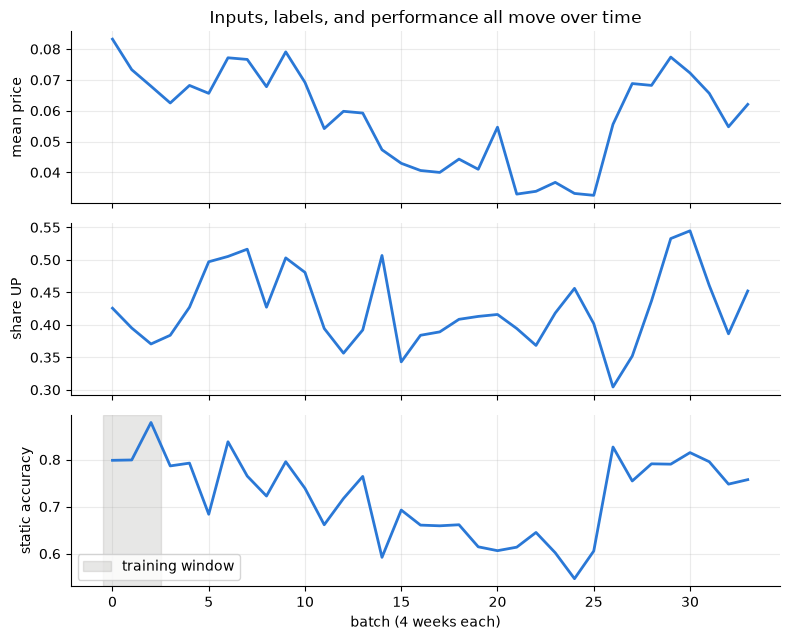

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(8, 6.5), sharex=True)
axes[0].plot(timeline["batch"], timeline["mean_nswprice"], color=BLUE)
axes[0].set(ylabel="mean price", title="Inputs, labels, and performance all move over time")
axes[1].plot(timeline["batch"], timeline["up_rate"], color=BLUE)
axes[1].set(ylabel="share UP")
axes[2].plot(timeline["batch"], timeline["accuracy"], color=BLUE)
axes[2].axvspan(-0.5, 2.5, color=GRAY, alpha=0.2, label="training window")
axes[2].set(ylabel="static accuracy", xlabel="batch (4 weeks each)")
axes[2].legend(loc="lower left")
plt.tight_layout()
plt.show()

**The five ways models go wrong** — with evidence from this very dataset (X = inputs, Y = label):

| Failure | What changes | Everyday example | Detectable without labels? |
|---|---|---|---|
| **Data drift** (covariate shift) | P(X): input distribution | a loan app launches in a new region; prices rise with inflation | ✅ compare input distributions |
| **Concept drift** | P(Y \| X): the relationship | fraudsters change tactics; a demand level that used to mean "price up" no longer does | ⚠️ mostly needs labels |
| **Label / prior shift** | P(Y): how common each class is | fraud rate doubles during holidays | ⚠️ partly (prediction rate moves) |
| **Training–serving skew** | features computed differently in production | training used "last 30 days" from a warehouse, serving uses "last 30 days" from a cache that lags | ✅ compare logged serving features with recomputed ones |
| **Upstream pipeline bugs** | a data source breaks, changes units, or fills in defaults | a column silently becomes all zeros after a schema change | ✅ data-quality checks |

In [4]:
current = df[df["batch"] == 20]
price_cut = reference["nswprice"].quantile(0.75)
vic_change_row = int(np.argmax(df["vicdemand"].to_numpy() != df["vicdemand"].iloc[0]))

print("DATA DRIFT      median nswprice: reference {:.3f} → batch 20 {:.3f}".format(reference["nswprice"].median(), current["nswprice"].median()))
print("CONCEPT DRIFT   P(UP | price above reference 75th pct): reference {:.1%} → batch 20 {:.1%}".format(
    reference.loc[reference["nswprice"] > price_cut, "y"].mean(), current.loc[current["nswprice"] > price_cut, "y"].mean()))
print("LABEL SHIFT     UP rate per batch ranges from {:.1%} to {:.1%}".format(timeline["up_rate"].min(), timeline["up_rate"].max()))
print(f"UPSTREAM ISSUE  vicprice/vicdemand/transfer hold one constant value for the first {vic_change_row:,} rows "
      f"(≈{vic_change_row / 48:.0f} days) — Victoria data was missing and filled in, so a model trained then can't use them")

DATA DRIFT      median nswprice: reference 0.071 → batch 20 0.034
CONCEPT DRIFT   P(UP | price above reference 75th pct): reference 86.0% → batch 20 72.5%
LABEL SHIFT     UP rate per batch ranges from 30.4% to 54.5%
UPSTREAM ISSUE  vicprice/vicdemand/transfer hold one constant value for the first 17,424 rows (≈363 days) — Victoria data was missing and filled in, so a model trained then can't use them


> 💡 **Interview angle:** "Data drift vs concept drift?" — data drift changes P(X) (what inputs look like); concept drift changes P(Y|X) (what the right answer is for the same input). Data drift can be seen without labels; concept drift usually needs labels or proxies, and it is the one that directly breaks a model.

## 2. What to Monitor 🟢

Monitor in **layers**, from cheapest/fastest to most meaningful/slowest:

| Layer | Examples | Needs labels? | Typical latency |
|---|---|---|---|
| **Service health** | request rate, error rate, latency p50/p99, timeouts | ❌ | seconds |
| **Data quality** | schema, missing values, ranges, types, duplicates, freshness | ❌ | minutes |
| **Feature distributions** | drift per feature vs reference (PSI, KS, …) | ❌ | hours–days |
| **Prediction distribution** | predicted-class rate, score distribution, confidence | ❌ | hours–days |
| **Model performance** | accuracy, AUC, calibration, per-segment metrics | ✅ (often delayed) | days–months |
| **Business KPIs** | revenue, approvals, fraud losses, click-through | sometimes | days–months |

Here's one monitoring snapshot for a single batch, including real latency measured on this laptop:

In [5]:
def latency_ms(bundle, frame, n=300):
    timings = []
    for i in range(n):
        row = frame.iloc[[i]]
        start = time.perf_counter()
        predict_proba(bundle, row)
        timings.append((time.perf_counter() - start) * 1000)
    return np.percentile(timings, [50, 99])


batch10 = df[df["batch"] == 10]
proba10 = predict_proba(static, batch10)
p50, p99 = latency_ms(static, batch10)
snapshot = {
    "rows": len(batch10),
    "missing_values": int(batch10[FEATURES].isna().sum().sum()),
    "latency_ms_p50": round(p50, 3),
    "latency_ms_p99": round(p99, 3),
    "mean_predicted_P(UP)": round(float(proba10.mean()), 3),
    "predicted_UP_rate": round(float((proba10 >= 0.5).mean()), 3),
    "reference_predicted_UP_rate": round(float((predict_proba(static, reference) >= 0.5).mean()), 3),
    "accuracy_when_labels_arrive": round(accuracy_score(batch10["y"], proba10 >= 0.5), 3),
}
for key, value in snapshot.items():
    print(f"{key:30s} {value}")

rows                           1344
missing_values                 0
latency_ms_p50                 0.909
latency_ms_p99                 1.815
mean_predicted_P(UP)           0.338
predicted_UP_rate              0.227
reference_predicted_UP_rate    0.36
accuracy_when_labels_arrive    0.739


Business KPIs aren't in this dataset, so we can't show them — but in a real system they're the metric your stakeholders actually care about, and a model can be "accurate" while a KPI falls.

> 💡 **Interview angle:** "What would you monitor for a deployed model?" — answer in layers: service health → data quality → feature drift → prediction drift → performance with delayed labels → business KPIs, and say which ones need labels.

## 3. PSI — Population Stability Index 🟡

PSI comes from credit scoring. It measures how much a distribution **shifted between bins**:

1. Cut the **reference** data into bins (usually 10 quantile bins, so each holds 10% of reference rows).
2. Compute the share of reference rows `r_i` and current rows `c_i` in each bin.
3. Sum: $\text{PSI} = \sum_i (c_i - r_i)\,\ln\dfrac{c_i}{r_i}$

Each term is ≥ 0 (both factors have the same sign), so PSI ≥ 0, and it's 0 only when the shares match. An empty bin would make `ln(0)` blow up, so we replace zero shares with a tiny ε.

**Common rule of thumb** (industry convention, not a law of nature):

| PSI | Reading |
|---|---|
| < 0.1 | no meaningful shift |
| 0.1 – 0.25 | moderate shift — investigate |
| > 0.25 | major shift — act |

In [6]:
def psi(reference, current, bins=10, eps=1e-4):
    """PSI with quantile bins taken from the reference sample."""
    reference, current = np.asarray(reference, dtype=float), np.asarray(current, dtype=float)
    inner = np.unique(np.quantile(reference, np.linspace(0, 1, bins + 1))[1:-1])
    edges = np.concatenate([[-np.inf], inner, [np.inf]])          # open ends catch values outside the reference range
    ref_share = np.histogram(reference, edges)[0] / len(reference)
    cur_share = np.histogram(current, edges)[0] / len(current)
    ref_share, cur_share = np.clip(ref_share, eps, None), np.clip(cur_share, eps, None)
    return float(np.sum((cur_share - ref_share) * np.log(cur_share / ref_share)))


def psi_label(value):
    return "no shift" if value < 0.1 else "moderate" if value < 0.25 else "MAJOR"


print("sanity: PSI(reference, reference) =", psi(reference["nswprice"], reference["nswprice"]))
table = pd.DataFrame({
    f"batch {b}": {c: psi(reference[c], df.loc[df["batch"] == b, c]) for c in ["period", "nswprice", "nswdemand"]}
    for b in (3, 20)
}).round(3)
table["batch 20 reading"] = table["batch 20"].map(psi_label)
print(table)

sanity: PSI(reference, reference) = 0.0
           batch 3  batch 20 batch 20 reading
period       0.000     0.000         no shift
nswprice     0.537     2.117            MAJOR
nswdemand    0.022     0.231         moderate


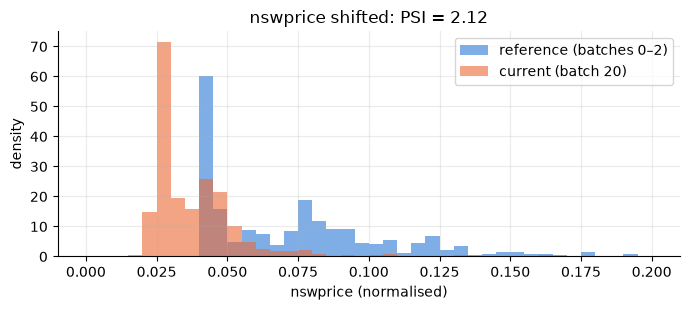

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.2))
bins = np.linspace(0, 0.2, 41)
ax.hist(reference["nswprice"], bins=bins, density=True, alpha=0.6, color=BLUE, label="reference (batches 0–2)")
ax.hist(current["nswprice"], bins=bins, density=True, alpha=0.6, color=ORANGE, label="current (batch 20)")
ax.set(xlabel="nswprice (normalised)", ylabel="density", title=f"nswprice shifted: PSI = {psi(reference['nswprice'], current['nswprice']):.2f}")
ax.legend()
plt.tight_layout()
plt.show()

### ✍️ Your Turn

PSI also works directly on category shares. A payment app's traffic by device was 50% iOS / 30% Android / 20% web last month and is 40% / 30% / 30% this month. Compute the PSI (no ε needed — no share is zero).

In [8]:
ref_shares = np.array([0.5, 0.3, 0.2])
cur_shares = np.array([0.4, 0.3, 0.3])
device_psi = None  # TODO: apply the PSI formula
check("device_psi", device_psi, 0.06286087, hint="np.sum((cur_shares - ref_shares) * np.log(cur_shares / ref_shares))")

⏳ device_psi: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
ref_shares = np.array([0.5, 0.3, 0.2])
cur_shares = np.array([0.4, 0.3, 0.3])
device_psi = float(np.sum((cur_shares - ref_shares) * np.log(cur_shares / ref_shares)))
check("device_psi", device_psi, 0.06286087)
```
≈ 0.063 → "no meaningful shift" by the rule of thumb, even though web traffic grew by half. Rules of thumb are a starting point, not a substitute for thinking about which change matters.
</details>

> 💡 **Interview angle:** "What PSI threshold do you use?" — the conventional 0.1 / 0.25 bands are a starting point; calibrate on historical periods where the model was known to be fine, and remember PSI depends on the binning (number and placement of bins) and on ε for empty bins.

## 4. Kolmogorov–Smirnov and Wasserstein 🟡

Both compare two numeric samples through their **empirical CDFs** — for every value x, the share of the sample that is ≤ x.

- **KS statistic** `D` = the **largest vertical gap** between the two CDFs, between 0 (identical) and 1 (no overlap). The **KS test** turns `D` and the sample sizes into a **p-value**: how surprising a gap this big would be if both samples came from the same distribution.
- **Wasserstein-1 distance** (a.k.a. earth mover's distance) = the **total area** between the two CDFs = how far, on average, you'd need to move probability mass to turn one distribution into the other — in the **feature's own units**. Evidently divides it by the reference standard deviation so one threshold fits all features.

```
  1 ┤        ____-----‾‾‾‾   reference CDF
    │     _-‾   ___----‾‾    current CDF
    │   _‾  __-‾   ↕ D = biggest gap        Wasserstein = shaded area between the curves
  0 ┼‾‾‾‾‾‾──────────────
```

In [9]:
def ks_statistic(a, b):
    a, b = np.sort(np.asarray(a, dtype=float)), np.sort(np.asarray(b, dtype=float))
    grid = np.concatenate([a, b])                                   # the CDFs only jump at observed values
    cdf_a = np.searchsorted(a, grid, side="right") / len(a)
    cdf_b = np.searchsorted(b, grid, side="right") / len(b)
    return float(np.max(np.abs(cdf_a - cdf_b)))


rows = []
for c in NUMERIC:
    ref_col, cur_col = reference[c], current[c]
    scipy_ks = stats.ks_2samp(ref_col, cur_col)
    assert np.isclose(ks_statistic(ref_col, cur_col), scipy_ks.statistic)
    rows.append({"feature": c, "KS D": scipy_ks.statistic, "KS p-value": scipy_ks.pvalue,
                 "Wasserstein": stats.wasserstein_distance(ref_col, cur_col),
                 "Wasserstein / ref std": stats.wasserstein_distance(ref_col, cur_col) / max(ref_col.std(ddof=0), 0.001),
                 "PSI": psi(ref_col, cur_col)})
print("our KS statistic matches scipy.stats.ks_2samp for every feature ✅")
print(pd.DataFrame(rows).set_index("feature").to_string(float_format=lambda v: f"{v:.3g}"))

our KS statistic matches scipy.stats.ks_2samp for every feature ✅
           KS D  KS p-value  Wasserstein  Wasserstein / ref std   PSI
feature                                                              
period        0           1            0                      0     0
nswprice  0.605   2.35e-321       0.0425                   1.19  2.12
nswdemand 0.214    5.45e-41       0.0537                  0.331 0.231
vicprice  0.836   3.11e-322      0.00567                   5.67  9.07
vicdemand 0.626   2.17e-321        0.132                    132  6.09
transfer  0.698   1.55e-321        0.148                    148  2.51


Notice `vicprice`, `vicdemand`, and `transfer`: the reference is **constant** (the filled-in values). Every score is enormous — PSI because all reference rows sit in one bin while current values spread out, and normalised Wasserstein even more so because it divides by a standard deviation of ~0. The numbers are "correct", but the story they suggest ("the world changed dramatically") is wrong: a data source came online. That's why data-quality checks come first (section 9).

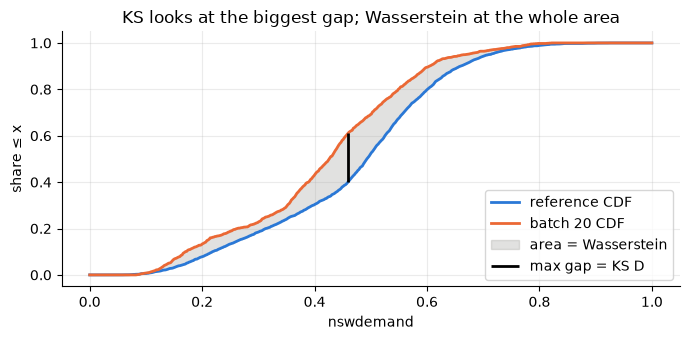

In [10]:
ecdf_ref = np.sort(reference["nswdemand"])
ecdf_cur = np.sort(current["nswdemand"])
grid = np.linspace(0, 1, 500)
F_ref = np.searchsorted(ecdf_ref, grid, side="right") / len(ecdf_ref)
F_cur = np.searchsorted(ecdf_cur, grid, side="right") / len(ecdf_cur)
gap_at = grid[np.argmax(np.abs(F_ref - F_cur))]

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(grid, F_ref, color=BLUE, label="reference CDF")
ax.plot(grid, F_cur, color=ORANGE, label="batch 20 CDF")
ax.fill_between(grid, F_ref, F_cur, color=GRAY, alpha=0.25, label="area = Wasserstein")
ax.vlines(gap_at, *sorted([F_ref[grid == gap_at][0], F_cur[grid == gap_at][0]]), color="black", linewidth=2, label="max gap = KS D")
ax.set(xlabel="nswdemand", ylabel="share ≤ x", title="KS looks at the biggest gap; Wasserstein at the whole area")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### ✍️ Your Turn

Compute the KS statistic **by hand** (reason it out, then type the number) for `a = [1, 2, 3, 4]` and `b = [3, 4, 5, 6]`. The checker compares with scipy.

In [11]:
a_small, b_small = [1, 2, 3, 4], [3, 4, 5, 6]
ks_by_hand = None  # TODO: a number between 0 and 1
check("ks_by_hand", ks_by_hand, float(stats.ks_2samp(a_small, b_small).statistic),
      hint="Evaluate both CDFs at x = 2, 3, 4: e.g. at x=2, F_a = 2/4 and F_b = 0/4.")

⏳ ks_by_hand: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
a_small, b_small = [1, 2, 3, 4], [3, 4, 5, 6]
ks_by_hand = 0.5          # at x=2: 0.50 vs 0.00; at x=3: 0.75 vs 0.25; at x=4: 1.00 vs 0.50 → max gap 0.5
check("ks_by_hand", ks_by_hand, float(stats.ks_2samp(a_small, b_small).statistic))
```
</details>

> 💡 **Interview angle:** "KS or Wasserstein?" — KS gives a bounded statistic plus a p-value but only reacts to the largest CDF gap and becomes "significant" for tiny shifts on big samples; Wasserstein measures how far mass moved in real units, which maps better to "does this shift matter?" — normalise it (e.g. by reference std) to use one threshold across features.

## 5. Categorical Drift: Chi-Square and Jensen–Shannon 🟡

For categories (device type, country, day of week, the predicted class):

- **Chi-square goodness-of-fit test** — expected counts = reference shares × current size; the statistic sums `(observed − expected)² / expected`, and the test gives a p-value.
- **Jensen–Shannon (JS) distance** — a symmetric, bounded version of KL divergence. With `m = (p + q)/2`: $\text{JS}(p, q) = \sqrt{\tfrac{1}{2}\text{KL}(p\|m) + \tfrac{1}{2}\text{KL}(q\|m)}$. With log base 2 it lies in **[0, 1]**; with natural log (scipy's default) in [0, √ln 2 ≈ 0.83].

Let's check two categoricals: **day of week** (should be stable — every batch covers whole weeks) and the **label** itself (prior shift).

In [12]:
def shares(series, categories):
    counts = series.value_counts().reindex(categories, fill_value=0)
    return counts.to_numpy(), counts.to_numpy() / counts.sum()


def js_distance(p, q, base=np.e):
    p, q = np.asarray(p, dtype=float) / np.sum(p), np.asarray(q, dtype=float) / np.sum(q)
    m = (p + q) / 2

    def kl(x, y):
        mask = x > 0                                               # 0 · log(0 / y) = 0 by convention
        return np.sum(x[mask] * np.log(x[mask] / y[mask])) / np.log(base)

    return float(np.sqrt((kl(p, m) + kl(q, m)) / 2))


for column, categories in [("day", list(range(1, 8))), ("y", [0, 1])]:
    ref_counts, ref_share = shares(reference[column], categories)
    cur_counts, cur_share = shares(current[column], categories)
    chi = stats.chisquare(cur_counts, f_exp=ref_share * cur_counts.sum())
    js = js_distance(ref_share, cur_share)
    assert np.isclose(js, jensenshannon(ref_share, cur_share))
    print(f"{column:4s} reference {np.round(ref_share, 3)} → batch 20 {np.round(cur_share, 3)} | "
          f"chi-square p = {chi.pvalue:.3g} | JS distance = {js:.3f}")

day  reference [0.143 0.143 0.143 0.143 0.143 0.143 0.143] → batch 20 [0.143 0.143 0.143 0.143 0.143 0.143 0.143] | chi-square p = 1 | JS distance = 0.000
y    reference [0.603 0.397] → batch 20 [0.584 0.416] | chi-square p = 0.158 | JS distance = 0.014


### ✍️ Your Turn

Compute the Jensen–Shannon distance **with log base 2** between the device shares from section 3 (`ref_shares`, `cur_shares`). Use the formula (or `js_distance` above) — the checker compares with `scipy.spatial.distance.jensenshannon(..., base=2)`.

In [13]:
device_js = None  # TODO
check("device_js", device_js, float(jensenshannon([0.5, 0.3, 0.2], [0.4, 0.3, 0.3], base=2)),
      hint="js_distance(ref_shares, cur_shares, base=2)")

⏳ device_js: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
device_js = js_distance(np.array([0.5, 0.3, 0.2]), np.array([0.4, 0.3, 0.3]), base=2)
check("device_js", device_js, float(jensenshannon([0.5, 0.3, 0.2], [0.4, 0.3, 0.3], base=2)))
```
</details>

> 💡 **Interview angle:** "How do you detect drift in a categorical feature with thousands of values (e.g. merchant id)?" — bucket rare values into "other" (or top-k + other), then use JS distance or PSI on the shares; a chi-square test on thousands of sparse cells is unreliable and hypersensitive at scale. Also watch the share of **new, unseen** categories.

## 6. Reference vs Current Windows 🟡

Drift is always *relative to something*. Common choices:

| Reference | Answers | Watch out |
|---|---|---|
| **Training data** (fixed) | "is production still like what the model learned?" | seasonal data always looks "drifted" |
| **Previous window** (sliding) | "did something change suddenly?" | slow, gradual drift is invisible |
| **Same period last year** (seasonal) | "is this unusual for the season?" | needs a year of history |

Let's compute the PSI of `nswdemand` for every batch under all three references (a "year" here is 13 batches = 52 weeks).

                          mean PSI  batches with PSI > 0.25  batches compared
fixed (training)             0.672                       18                31
sliding (previous batch)     0.255                       14                31
seasonal (52 weeks ago)      0.121                        4                21


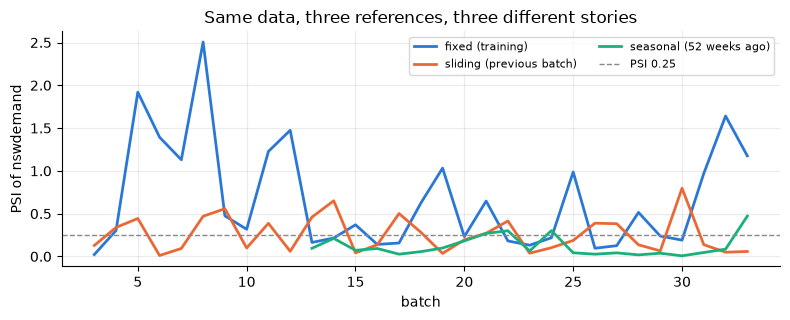

In [14]:
windows = []
for b in range(3, df["batch"].max() + 1):
    cur_vals = df.loc[df["batch"] == b, "nswdemand"]
    windows.append({
        "batch": b,
        "fixed (training)": psi(reference["nswdemand"], cur_vals),
        "sliding (previous batch)": psi(df.loc[df["batch"] == b - 1, "nswdemand"], cur_vals),
        "seasonal (52 weeks ago)": psi(df.loc[df["batch"] == b - 13, "nswdemand"], cur_vals) if b >= 13 else np.nan,
    })
windows = pd.DataFrame(windows).set_index("batch")
summary = pd.DataFrame({"mean PSI": windows.mean(), "batches with PSI > 0.25": (windows > 0.25).sum(), "batches compared": windows.notna().sum()})
print(summary.round(3))

fig, ax = plt.subplots(figsize=(8, 3.3))
for column, color in zip(windows.columns, [BLUE, ORANGE, AQUA]):
    ax.plot(windows.index, windows[column], color=color, label=column)
ax.axhline(0.25, color=GRAY, linestyle="--", linewidth=1, label="PSI 0.25")
ax.set(xlabel="batch", ylabel="PSI of nswdemand", title="Same data, three references, three different stories")
ax.legend(ncols=2, fontsize=8)
plt.tight_layout()
plt.show()

Demand is seasonal (winter heating, summer cooling), so comparing to the fixed training window flags many batches that are perfectly normal for their time of year. There is no single right reference — production systems often track two (e.g. training + previous window).

> 💡 **Interview angle:** "What reference window would you use?" — tie it to the question: training data to detect "the model is out of its depth", a sliding window for sudden breaks, and a seasonal window when the business has strong seasonality. Keep windows disjoint and large enough for stable statistics.

## 7. Sample Size: Why p-Values Mislead at Scale 🔴

A statistical test answers *"is there **any** difference?"*, not *"is the difference **big enough to matter**?"*. With enough data, every tiny difference becomes "statistically significant". Production batches often have millions of rows.

To show this cleanly we use a **controlled synthetic** example: reference ~ Normal(0, 1), current ~ Normal(0.05, 1) — a shift of 5% of a standard deviation that no model would care about — and grow the sample size.

              KS p-value   KS D     PSI  Wasserstein/std
n per window                                            
100                 0.19   0.15   0.262            0.216
1000               0.783  0.029  0.0175           0.0333
10000           1.12e-06 0.0379 0.00809           0.0811
100000          5.27e-32  0.027 0.00345           0.0582
1000000        8.47e-184 0.0205  0.0024           0.0503

from n = 10,000 the KS test says 'significant drift' (p = 1.1e-06), yet PSI = 0.0081 (< 0.1, no meaningful shift)


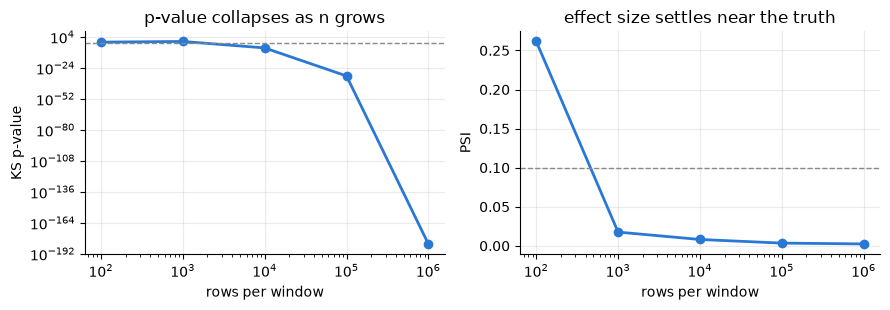

In [15]:
sizes = [100, 1_000, 10_000, 100_000, 1_000_000]
scale_rows = []
for n in sizes:
    ref_sample = rng.normal(0.0, 1.0, n)
    cur_sample = rng.normal(0.05, 1.0, n)
    ks = stats.ks_2samp(ref_sample, cur_sample, method="asymp")
    scale_rows.append({"n per window": n, "KS p-value": ks.pvalue, "KS D": ks.statistic,
                       "PSI": psi(ref_sample, cur_sample), "Wasserstein/std": stats.wasserstein_distance(ref_sample, cur_sample) / ref_sample.std()})
scale = pd.DataFrame(scale_rows).set_index("n per window")
print(scale.to_string(float_format=lambda v: f"{v:.3g}"))

significant = scale[scale["KS p-value"] < 0.05]
if len(significant):
    n_sig = significant.index[0]
    print(f"\nfrom n = {n_sig:,} the KS test says 'significant drift' (p = {significant['KS p-value'].iloc[0]:.2g}), "
          f"yet PSI = {significant['PSI'].iloc[0]:.4f} (< 0.1, no meaningful shift)")

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
axes[0].loglog(scale.index, scale["KS p-value"], "o-", color=BLUE)
axes[0].axhline(0.05, color=GRAY, linestyle="--", linewidth=1)
axes[0].set(xlabel="rows per window", ylabel="KS p-value", title="p-value collapses as n grows")
axes[1].semilogx(scale.index, scale["PSI"], "o-", color=BLUE)
axes[1].axhline(0.1, color=GRAY, linestyle="--", linewidth=1)
axes[1].set(xlabel="rows per window", ylabel="PSI", title="effect size settles near the truth")
plt.tight_layout()
plt.show()

PSI is noisy (and biased upward) for small samples, then settles; the p-value keeps falling forever. **Use effect sizes (PSI, Wasserstein, JS) with calibrated thresholds for large batches**, and reserve p-values for small samples — which is exactly what Evidently's defaults do (KS/chi-square when the reference has ≤ 1,000 rows, distances above that; see section 13).

> 💡 **Interview angle:** "Why not alert when the KS p-value < 0.05?" — with 100k+ rows a p-value measures sample size more than drift: tiny, harmless shifts become "significant", so the alert fires constantly. Use an effect-size metric with a threshold calibrated on history, or subsample to a fixed size.

## 8. Alert Thresholds, False Alarms, and Multiple Testing 🔴

Suppose you test **k** independent features every day at α = 0.05. Even if nothing drifted, the chance that **at least one** alarms is the **family-wise error rate**: $\text{FWER} = 1 - (1-\alpha)^k$. For 50 features that's 92% — an alarm almost every day. People stop reading alerts (**alert fatigue**), and then miss the real one.

Fixes:
- **Bonferroni:** test each feature at α/k (controls FWER; conservative).
- **Benjamini–Hochberg (BH):** controls the **false discovery rate** — the expected share of alarms that are false (less conservative; `scipy.stats.false_discovery_control`).
- **Effect-size thresholds + persistence ("debounce")**: alert only if a feature exceeds the threshold for 2+ consecutive windows, and prioritise features the model relies on.

**An A/A test on real data.** Split the reference window randomly into two halves many times — there is *no* drift by construction — and count alarms on the 4 features that vary in the reference.

In [16]:
varying = [c for c in FEATURES if reference[c].nunique() > 1]
split_rng = np.random.default_rng(7)
alarms_any, alarms_any_bonf, per_feature = 0, 0, np.zeros(len(varying))
n_splits = 200
for _ in range(n_splits):
    mask = split_rng.random(len(reference)) < 0.5
    pvals = np.array([stats.ks_2samp(reference.loc[mask, c], reference.loc[~mask, c], method="asymp").pvalue for c in varying])
    per_feature += pvals < 0.05
    alarms_any += (pvals < 0.05).any()
    alarms_any_bonf += (pvals < 0.05 / len(varying)).any()

print(f"features tested: {varying}")
print(f"per-feature false alarm rate at α=0.05: {np.round(per_feature / n_splits, 3)}")
print(f"'any feature alarms' rate: {alarms_any / n_splits:.1%} (theory for 4 independent continuous tests: {1 - 0.95 ** 4:.1%})")
print(f"with Bonferroni (α/4 = {0.05 / 4:.4f}): {alarms_any_bonf / n_splits:.1%}")
print("(day and period take few distinct values; the KS test is conservative on such discrete data, so their rates sit below 5%)")

features tested: ['day', 'period', 'nswprice', 'nswdemand']
per-feature false alarm rate at α=0.05: [0.005 0.055 0.025 0.035]
'any feature alarms' rate: 11.0% (theory for 4 independent continuous tests: 18.5%)
with Bonferroni (α/4 = 0.0125): 2.0%
(day and period take few distinct values; the KS test is conservative on such discrete data, so their rates sit below 5%)


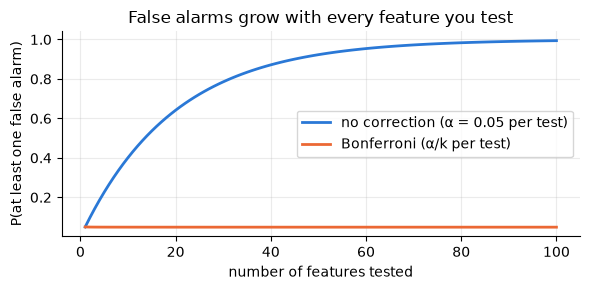

In [17]:
k = np.arange(1, 101)
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(k, 1 - 0.95 ** k, color=BLUE, label="no correction (α = 0.05 per test)")
ax.plot(k, 1 - (1 - 0.05 / k) ** k, color=ORANGE, label="Bonferroni (α/k per test)")
ax.set(xlabel="number of features tested", ylabel="P(at least one false alarm)", title="False alarms grow with every feature you test")
ax.legend()
plt.tight_layout()
plt.show()

**Real data is rarely stationary even when "nothing is wrong".** Compare consecutive 4-week batches *inside the first year*, when the model was working fine:

In [18]:
consecutive = pd.DataFrame([{
    "pair": f"{b}→{b + 1}",
    "KS p (nswdemand)": stats.ks_2samp(df.loc[df["batch"] == b, "nswdemand"], df.loc[df["batch"] == b + 1, "nswdemand"]).pvalue,
    "PSI (nswdemand)": psi(df.loc[df["batch"] == b, "nswdemand"], df.loc[df["batch"] == b + 1, "nswdemand"]),
} for b in range(0, 11)])
print(consecutive.to_string(index=False, float_format=lambda v: f"{v:.3g}"))
print(f"\n{(consecutive['KS p (nswdemand)'] < 0.05).mean():.0%} of 'normal' month-to-month comparisons are 'significant' at 0.05; "
      f"{(consecutive['PSI (nswdemand)'] > 0.25).mean():.0%} exceed PSI 0.25 → calibrate thresholds on history like this.")

 pair  KS p (nswdemand)  PSI (nswdemand)
  0→1          5.97e-38             0.34
  1→2           2.9e-13            0.131
  2→3          1.86e-14            0.129
  3→4          1.55e-30            0.339
  4→5          9.55e-36            0.443
  5→6             0.841           0.0107
  6→7          3.07e-05           0.0936
  7→8          7.73e-52             0.47
  8→9          8.81e-55            0.558
 9→10          1.76e-05            0.099
10→11          3.46e-14            0.387

91% of 'normal' month-to-month comparisons are 'significant' at 0.05; 55% exceed PSI 0.25 → calibrate thresholds on history like this.


### ✍️ Your Turn

`batch5_pvalues` holds real KS p-values for the model's 4 varying features in batch 5 vs the reference. How many features alarm **after a Bonferroni correction** at family-wise α = 0.05? Store an integer in `n_bonferroni_alarms`.

In [19]:
batch5 = df[df["batch"] == 5]
batch5_pvalues = {c: stats.ks_2samp(reference[c], batch5[c]).pvalue for c in varying}
print({c: f"{p:.2g}" for c, p in batch5_pvalues.items()})
n_bonferroni_alarms = None  # TODO
check("n_bonferroni_alarms", n_bonferroni_alarms, int(sum(p < 0.05 / len(batch5_pvalues) for p in batch5_pvalues.values())),
      hint="Compare each p-value with 0.05 / number_of_tests and count.")

{'day': '1', 'period': '1', 'nswprice': '6e-65', 'nswdemand': '2.3e-133'}
⏳ n_bonferroni_alarms: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
batch5 = df[df["batch"] == 5]
batch5_pvalues = {c: stats.ks_2samp(reference[c], batch5[c]).pvalue for c in varying}
threshold = 0.05 / len(batch5_pvalues)
n_bonferroni_alarms = sum(p < threshold for p in batch5_pvalues.values())
check("n_bonferroni_alarms", n_bonferroni_alarms, int(sum(p < 0.05 / len(batch5_pvalues) for p in batch5_pvalues.values())))
```
</details>

> 💡 **Interview angle:** "You monitor 300 features and get drift alerts every day. What do you do?" — false alarms scale with the number of tests: switch to effect-size thresholds calibrated on stable history, correct for multiple testing (Bonferroni/BH), require persistence, weight by feature importance, and alert on model-level signals (prediction drift, performance) first.

## 9. Data-Quality Validators 🟢

Most "model problems" in production are **data problems**: a renamed column, a unit change, a join that starts producing nulls, a source that silently fills in defaults. Cheap validators catch them before any drift statistic is computed. (Libraries such as Great Expectations, Pandera, and Evidently's tests formalise this; the logic is simple enough to write yourself.)

In [20]:
def validate(frame, reference, max_null_rate=0.01, max_out_of_range=0.01):
    """Return a list of (check, message) problems for a batch compared with a reference window."""
    problems = []
    missing = [c for c in FEATURES if c not in frame.columns]
    if missing:
        problems.append(("schema", f"missing columns {missing}"))
    for c in [c for c in FEATURES if c in frame.columns]:
        null_rate = frame[c].isna().mean()
        if null_rate > max_null_rate:
            problems.append(("missing values", f"{c}: {null_rate:.1%} null"))
        if reference[c].nunique() == 1:
            if frame[c].nunique() > 1:
                problems.append(("constant changed", f"{c}: constant in reference, {frame[c].nunique()} distinct values now"))
            continue
        lo, hi = reference[c].min(), reference[c].max()
        margin = 0.1 * (hi - lo)
        outside = ((frame[c] < lo - margin) | (frame[c] > hi + margin)).mean()
        if outside > max_out_of_range:
            problems.append(("range", f"{c}: {outside:.1%} of values outside reference range [{lo:.3f}, {hi:.3f}] ±10%"))
    return problems


# a deliberately corrupted copy of batch 20 (synthetic corruption on real data) simulating three upstream bugs
corrupted = df[df["batch"] == 20].copy()
null_rows = corrupted.sample(frac=0.05, random_state=0).index
corrupted.loc[null_rows, "nswdemand"] = np.nan                    # a join started dropping values
corrupted["nswprice"] = corrupted["nswprice"] * 100                # someone changed the unit
corrupted = corrupted.rename(columns={"transfer": "transfer_mw"})  # a schema change upstream

for name, frame in [("batch 3", df[df["batch"] == 3]), ("batch 13", df[df["batch"] == 13]), ("batch 20 (corrupted copy)", corrupted)]:
    found = validate(frame, reference)
    print(f"\n{name}: {len(found)} problem(s)")
    for check_name, message in found:
        print(f"  ❗ {check_name:16s} {message}")


batch 3: 0 problem(s)

batch 13: 3 problem(s)
  ❗ constant changed vicprice: constant in reference, 966 distinct values now
  ❗ constant changed vicdemand: constant in reference, 946 distinct values now
  ❗ constant changed transfer: constant in reference, 643 distinct values now

batch 20 (corrupted copy): 5 problem(s)
  ❗ schema           missing columns ['transfer']
  ❗ range            nswprice: 100.0% of values outside reference range [0.041, 0.299] ±10%
  ❗ missing values   nswdemand: 5.0% null
  ❗ constant changed vicprice: constant in reference, 817 distinct values now
  ❗ constant changed vicdemand: constant in reference, 984 distinct values now


Batch 13 is real: the Victoria columns start varying (the data source came online). Nothing is "broken", but a model trained on the constant period can't use them — a validator makes that visible instead of silently ignoring it.

### ✍️ Your Turn

Write `columns_over_null_rate(frame, max_rate)` returning the **sorted list** of feature columns (from `FEATURES`, when present) whose share of missing values is **greater than** `max_rate`.

In [21]:
def columns_over_null_rate(frame, max_rate):
    return None  # TODO


got = columns_over_null_rate(corrupted, 0.01)
check("columns_over_null_rate", got, ["nswdemand"], hint="frame[c].isna().mean() > max_rate for c in FEATURES if c in frame.columns")

⏳ columns_over_null_rate: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def columns_over_null_rate(frame, max_rate):
    return sorted(c for c in FEATURES if c in frame.columns and frame[c].isna().mean() > max_rate)


got = columns_over_null_rate(corrupted, 0.01)
check("columns_over_null_rate", got, ["nswdemand"])
```
</details>

> 💡 **Interview angle:** "Where do you put data validation?" — at every boundary: when data lands (ingestion), before training (fail the pipeline), and at serving (log and alert, maybe fall back to defaults). Validate schema, nulls, ranges, categories, freshness, and row counts; most production incidents are caught here, not by drift tests.

## 10. Monitoring Without Labels 🟡

Labels are often **late** (loan defaults take months), **partial** (you only learn outcomes for approved loans), or **never** available. Label-free signals:

- **Prediction drift** — PSI of the model's scores vs its scores on the reference data.
- **Predicted-class rate** — e.g. suddenly approving 40% instead of 25%.
- **Confidence** — the share of uncertain predictions (scores near 0.5) often rises on unfamiliar inputs.
- **Feature drift** — weighted by feature importance.
- **Proxies** — user corrections, complaints, overrides by human reviewers, click-through.

Do these signals actually track the (hidden) accuracy? Let's measure on the static model.

Spearman correlation with the true (hidden) accuracy:
prediction PSI              -0.76
max feature PSI             -0.66
uncertain share (0.4–0.6)    0.78
predicted UP rate            0.87

strongest label-free signal: 'predicted UP rate' (ρ = 0.87)
batches with a MAJOR feature drift but accuracy within 3 points of the first months: 15 of 31


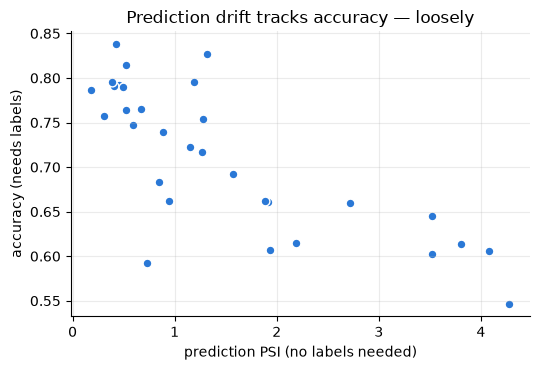

In [22]:
ref_pred = predict_proba(static, reference)
proxy_rows = []
for b in range(3, df["batch"].max() + 1):
    g = df[df["batch"] == b]
    p = predict_proba(static, g)
    proxy_rows.append({
        "batch": b,
        "accuracy": accuracy_score(g["y"], p >= 0.5),
        "prediction PSI": psi(ref_pred, p),
        "max feature PSI": max(psi(reference[c], g[c]) for c in static["features"]),
        "predicted UP rate": (p >= 0.5).mean(),
        "uncertain share (0.4–0.6)": ((p > 0.4) & (p < 0.6)).mean(),
    })
proxies = pd.DataFrame(proxy_rows).set_index("batch")
correlations = proxies.corr(method="spearman")["accuracy"].drop("accuracy").sort_values()
print("Spearman correlation with the true (hidden) accuracy:")
print(correlations.round(2).to_string())
print(f"\nstrongest label-free signal: '{correlations.abs().idxmax()}' (ρ = {correlations[correlations.abs().idxmax()]:.2f})")

drift_no_harm = proxies[(proxies["max feature PSI"] > 0.25) & (proxies["accuracy"] >= proxies["accuracy"].iloc[:3].mean() - 0.03)]
print(f"batches with a MAJOR feature drift but accuracy within 3 points of the first months: {len(drift_no_harm)} of {len(proxies)}")

fig, ax = plt.subplots(figsize=(5.5, 3.8))
ax.scatter(proxies["prediction PSI"], proxies["accuracy"], s=40, color=BLUE, edgecolor="white", linewidth=1)
ax.set(xlabel="prediction PSI (no labels needed)", ylabel="accuracy (needs labels)", title="Prediction drift tracks accuracy — loosely")
plt.tight_layout()
plt.show()

Label-free signals are **early warnings**, not a replacement for performance: they correlate with accuracy here, but plenty of drifted batches were still handled fine, and concept drift can hurt accuracy with no input drift at all.

> 💡 **Interview angle:** "How do you detect problems without labels?" — monitor prediction distribution and confidence, feature drift weighted by importance, data quality, and business proxies; validate on history that the proxy actually correlates with performance, and get a small stream of labels (human review, delayed outcomes) to confirm.

## 11. Delayed Labels and Performance Monitoring 🟡

When labels arrive, compute performance **per window** — but a single batch's accuracy is noisy. Put an interval around it so you alert on real drops, not bad luck. The **Wilson score interval** for a proportion p̂ from n trials (z = 1.96 for 95%):

$$\frac{\hat p + \frac{z^2}{2n} \pm z\sqrt{\frac{\hat p(1-\hat p)}{n} + \frac{z^2}{4n^2}}}{1 + \frac{z^2}{n}}$$

Alert rule: **the whole interval** sits below a baseline accuracy minus a tolerance. Which baseline? A validation score from a single batch can be optimistic, so we compare it with the accuracy measured on the first production batches once their labels arrive. Here labels for batch *b* arrive at the end of batch *b*, so the earliest we can react is before batch *b + 1*. (Caveat: consecutive half-hours are correlated, so the real uncertainty is wider than this interval assumes.)

single-batch validation accuracy: 86.8% | production baseline (batches 3–4): 78.9% → validation was optimistic; using the production baseline
alert when the 95% interval is entirely below 73.9%
first alert at batch 5 → react before batch 6; 14 of 29 batches alert


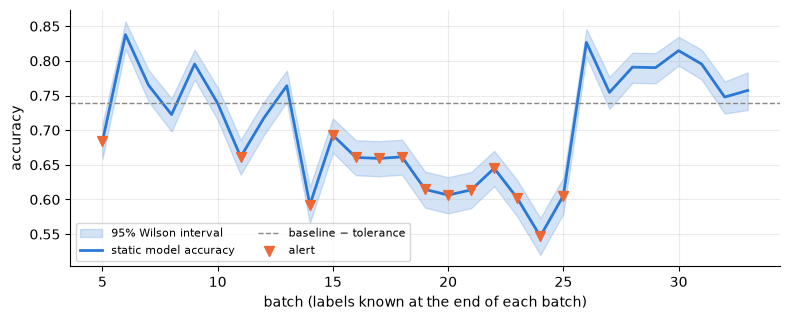

In [23]:
def wilson_interval(successes, n, z=1.959964):
    p_hat = successes / n
    denom = 1 + z**2 / n
    center = (p_hat + z**2 / (2 * n)) / denom
    half = z * np.sqrt(p_hat * (1 - p_hat) / n + z**2 / (4 * n**2)) / denom
    return center - half, center + half


val_model = train_model(df[df["batch"] < 2])                       # time-based validation: train 0–1, validate on 2
val_batch = df[df["batch"] == 2]
validation_accuracy = accuracy_score(val_batch["y"], predict_proba(val_model, val_batch) >= 0.5)
BASELINE_BATCHES = [3, 4]                                          # first two production batches, once their labels arrived
reference_accuracy = float(np.mean([accuracy_score(df.loc[df["batch"] == b, "y"], predict_proba(static, df[df["batch"] == b]) >= 0.5)
                                    for b in BASELINE_BATCHES]))
TOLERANCE = 0.05
print(f"single-batch validation accuracy: {validation_accuracy:.1%} | production baseline (batches 3–4): {reference_accuracy:.1%} "
      f"→ {'validation was optimistic; using the production baseline' if validation_accuracy > reference_accuracy else 'using the production baseline'}")

perf = []
for b in range(BASELINE_BATCHES[-1] + 1, df["batch"].max() + 1):
    g = df[df["batch"] == b]
    correct = int(((predict_proba(static, g) >= 0.5) == g["y"]).sum())
    lo, hi = wilson_interval(correct, len(g))
    perf.append({"batch": b, "accuracy": correct / len(g), "low": lo, "high": hi, "alert": hi < reference_accuracy - TOLERANCE})
perf = pd.DataFrame(perf).set_index("batch")
first_alert = perf.index[perf["alert"]].min()
print(f"alert when the 95% interval is entirely below {reference_accuracy - TOLERANCE:.1%}")
if perf["alert"].any():
    print(f"first alert at batch {first_alert} → react before batch {first_alert + 1}; {int(perf['alert'].sum())} of {len(perf)} batches alert")
else:
    print("no batch alerts")

fig, ax = plt.subplots(figsize=(8, 3.3))
ax.fill_between(perf.index, perf["low"], perf["high"], color=BLUE, alpha=0.2, label="95% Wilson interval")
ax.plot(perf.index, perf["accuracy"], color=BLUE, label="static model accuracy")
ax.axhline(reference_accuracy - TOLERANCE, color=GRAY, linestyle="--", linewidth=1, label="baseline − tolerance")
ax.scatter(perf.index[perf["alert"]], perf.loc[perf["alert"], "accuracy"], marker="v", s=50, color=ORANGE, zorder=3, label="alert")
ax.set(xlabel="batch (labels known at the end of each batch)", ylabel="accuracy")
ax.legend(fontsize=8, ncols=2)
plt.tight_layout()
plt.show()

### ✍️ Your Turn

A fraud model got 800 of 1,000 delayed labels right this week. Use `wilson_interval` to compute the 95% interval and store it as a tuple `(low, high)`. The checker compares with scipy's `binomtest(...).proportion_ci(method="wilson")`.

In [24]:
week_interval = None  # TODO
reference_ci = stats.binomtest(800, 1000).proportion_ci(confidence_level=0.95, method="wilson")
check("week_interval", week_interval, (float(reference_ci.low), float(reference_ci.high)), hint="wilson_interval(800, 1000)")

⏳ week_interval: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
week_interval = tuple(float(v) for v in wilson_interval(800, 1000))
reference_ci = stats.binomtest(800, 1000).proportion_ci(confidence_level=0.95, method="wilson")
check("week_interval", week_interval, (float(reference_ci.low), float(reference_ci.high)))
```
About ±2.5 points: with 1,000 labels, a 2-point accuracy dip is indistinguishable from noise.
</details>

> 💡 **Interview angle:** "Labels arrive 60 days late — how do you monitor performance?" — track label-free signals in real time, compute performance per cohort (by prediction date) as labels mature, use intervals and minimum sample sizes before alerting, and consider early proxies (e.g. first-payment default instead of 12-month default).

## 12. Retraining Triggers and Strategies 🟡

| Strategy | How | Pros | Cons |
|---|---|---|---|
| **Static** | never retrain | simple, stable | decays |
| **Scheduled** | every N days/weeks | predictable, easy to operate | wastes compute when stable; slow when things break |
| **Triggered** | when performance drops or drift exceeds a threshold | spends compute when needed | needs trustworthy signals; alert noise → too many retrains |
| **Continuous / online** | update on every new batch or example | adapts fastest | risk of learning from bad data, feedback loops, harder to validate |

**Which data to retrain on?** A **sliding window** (recent data only) adapts to concept drift but forgets rare/seasonal patterns; an **expanding window** (all data so far) is stable but slow to adapt. Always add **guardrails**: minimum labeled rows, a cooldown between retrains, and **validate the new model against the current one** before promoting it.

Sliding vs expanding, retraining every 3 batches:

In [25]:
def replay_scheduled(window_kind, every=3, window=3):
    bundle, trained_through, accuracies = train_model(df[df["batch"] < 3]), 2, []
    for b in range(3, df["batch"].max() + 1):
        g = df[df["batch"] == b]
        accuracies.append(accuracy_score(g["y"], predict_proba(bundle, g) >= 0.5))
        if b - trained_through >= every:
            lower = b - window + 1 if window_kind == "sliding" else 0
            bundle, trained_through = train_model(df[(df["batch"] >= lower) & (df["batch"] <= b)]), b
    return float(np.mean(accuracies))


window_results = {"static (never)": float(proxies["accuracy"].mean()),
                  "sliding window (last 12 weeks)": replay_scheduled("sliding"),
                  "expanding window (all history)": replay_scheduled("expanding")}
for name, acc in window_results.items():
    print(f"{name:32s} mean accuracy over batches 3–33: {acc:.1%}")
best_window = max(window_results, key=window_results.get)
print(f"→ best here: {best_window} — ELEC2 has strong concept drift, so recent data beats all history")

static (never)                   mean accuracy over batches 3–33: 71.1%
sliding window (last 12 weeks)   mean accuracy over batches 3–33: 75.6%
expanding window (all history)   mean accuracy over batches 3–33: 74.2%
→ best here: sliding window (last 12 weeks) — ELEC2 has strong concept drift, so recent data beats all history


A reusable trigger with guardrails (we'll use this logic in the mini project):

```python
def should_retrain(batch_accuracy, validation_accuracy, batches_since_retrain, labeled_rows,
                   tolerance=0.05, cooldown=2, min_labeled_rows=500):
    if labeled_rows < min_labeled_rows or batches_since_retrain < cooldown:
        return False                                   # not enough evidence, or we just retrained
    return batch_accuracy < validation_accuracy - tolerance
```

> 💡 **Interview angle:** "How do you choose a retraining cadence?" — measure how fast performance decays on historical replays (like this notebook), compare the cost of stale predictions with the cost of retraining and deployment risk, start scheduled at a cadence shorter than the decay time, and add performance/drift triggers with guardrails; re-evaluate the cadence as data volume and drift change.

## 13. Evidently Reports 🟡

**Evidently** is an open-source Python library that computes data-drift, data-quality, and model-quality metrics and renders them as interactive HTML reports (and JSON). The 0.7 API:

```python
from evidently import Dataset, DataDefinition, Report, BinaryClassification
from evidently.presets import DataDriftPreset, ClassificationPreset
snapshot = Report([DataDriftPreset()]).run(reference_data=ref_dataset, current_data=cur_dataset)
snapshot.save_html("report.html"); snapshot.dict()   # → numbers you can log or alert on
```

**How `DataDriftPreset` picks a test** (read from Evidently 0.7's source, `_get_default_stattest`):

| Reference rows | Numerical column (> 5 unique values) | Categorical / ≤ 5 unique values | Threshold |
|---|---|---|---|
| ≤ 1,000 | KS test p-value | chi-square p-value (Z-test if binary) | drift if p < 0.05 |
| > 1,000 | Wasserstein distance ÷ reference std | Jensen–Shannon distance | drift if ≥ 0.1 |

The whole dataset counts as drifted when the share of drifted columns is **≥ `drift_share`** (default 0.5). Our reference has 4,032 rows, so expect Wasserstein and Jensen–Shannon.

In [26]:
def with_predictions(frame, bundle):
    proba = predict_proba(bundle, frame)
    return frame[FEATURES + ["y"]].assign(prob_up=proba, prediction=(proba >= 0.5).astype(int))


if not HAS_EVIDENTLY:
    print("⏭️ Skipped: Evidently is not installed. Run `pip install evidently` in a separate environment (see ⚙️ Setup).")
else:
    from evidently import BinaryClassification, DataDefinition, Dataset, Report
    from evidently.presets import ClassificationPreset, DataDriftPreset

    definition = DataDefinition(numerical_columns=NUMERIC + ["prob_up"], categorical_columns=["day"],
                                classification=[BinaryClassification(target="y", prediction_labels="prediction")])
    ref_ds = Dataset.from_pandas(with_predictions(reference, static), data_definition=definition)
    cur_frame = with_predictions(current, static)
    cur_ds = Dataset.from_pandas(cur_frame, data_definition=definition)

    drift_snapshot = Report([DataDriftPreset(columns=FEATURES + ["prob_up"])]).run(reference_data=ref_ds, current_data=cur_ds)
    drift_path = OUTPUT_DIR / "evidently_data_drift_batch20.html"
    drift_snapshot.save_html(str(drift_path))

    drift_rows, summary_value = [], None
    for metric in drift_snapshot.dict()["metrics"]:
        config = metric["config"]
        if config["type"].endswith("DriftedColumnsCount"):
            summary_value = metric["value"]
        elif config["type"].endswith("ValueDrift"):
            is_p_value = "p_value" in config["method"]
            drifted = metric["value"] < config["threshold"] if is_p_value else metric["value"] >= config["threshold"]
            drift_rows.append({"column": config["column"], "method": config["method"], "score": metric["value"],
                               "threshold": config["threshold"], "drifted": drifted})
    print(pd.DataFrame(drift_rows).to_string(index=False, float_format=lambda v: f"{v:.3f}"))
    print(f"\ndrifted columns: {summary_value['count']:.0f} ({summary_value['share']:.0%}) → report saved to {drift_path}")

   column                        method   score  threshold  drifted
      day       Jensen-Shannon distance   0.000      0.100    False
   period Wasserstein distance (normed)   0.000      0.100    False
 nswprice Wasserstein distance (normed)   1.190      0.100     True
nswdemand Wasserstein distance (normed)   0.331      0.100     True
 vicprice Wasserstein distance (normed)   5.674      0.100     True
vicdemand Wasserstein distance (normed) 131.616      0.100     True
 transfer Wasserstein distance (normed) 147.774      0.100     True
  prob_up Wasserstein distance (normed)   0.832      0.100     True

drifted columns: 6 (75%) → report saved to _outputs/evidently_data_drift_batch20.html


In [27]:
if HAS_EVIDENTLY:
    quality_snapshot = Report([ClassificationPreset()]).run(reference_data=ref_ds, current_data=cur_ds)
    quality_path = OUTPUT_DIR / "evidently_classification_batch20.html"
    quality_snapshot.save_html(str(quality_path))
    quality = {m["metric_name"].split("(")[0]: m["value"] for m in quality_snapshot.dict()["metrics"]}
    for name in ["Accuracy", "Precision", "Recall", "F1Score"]:
        print(f"{name:9s} (current batch 20): {quality[name]:.3f}")
    assert np.isclose(quality["Accuracy"], accuracy_score(cur_frame["y"], cur_frame["prediction"]))
    print(f"matches scikit-learn's accuracy ✅ → report saved to {quality_path}")
    print("the HTML reports include reference-vs-current comparisons, confusion matrices, and per-column distribution plots")

Accuracy  (current batch 20): 0.606
Precision (current batch 20): 0.683
Recall    (current batch 20): 0.100
F1Score   (current batch 20): 0.175
matches scikit-learn's accuracy ✅ → report saved to _outputs/evidently_classification_batch20.html
the HTML reports include reference-vs-current comparisons, confusion matrices, and per-column distribution plots


> 💡 **Interview angle:** "How would you productionise drift reports?" — run them as a scheduled job (e.g. Airflow) per window, store the JSON metrics (not just HTML) in a metrics store, alert on a few model-level metrics, and link the HTML report from the alert for investigation.

## 14. Shadow and Canary Deployments, Architecture, and LLM Apps 🟢

**Before a new model takes traffic**, monitor it safely:

- **Shadow deployment** — the challenger receives a copy of real requests and makes predictions that are **logged, not used**. Compare its predictions (and later its accuracy) with the champion's. Zero user risk.
- **Canary deployment** — route a small share (1–10%) of real traffic to the challenger, watch service health, prediction distribution, and business KPIs, then ramp up or roll back.
- **A/B test** — split traffic for long enough to measure the business impact with a proper statistical test.

A real shadow comparison: the champion is our static model; the challenger was retrained on batches 17–19; both score batch 20.

In [28]:
challenger = train_model(df[df["batch"].between(17, 19)])
champion_pred = predict_proba(static, current) >= 0.5
challenger_pred = predict_proba(challenger, current) >= 0.5
agreement = (champion_pred == challenger_pred).mean()
champ_acc, chall_acc = accuracy_score(current["y"], champion_pred), accuracy_score(current["y"], challenger_pred)
print(f"shadow phase (no labels yet): the models agree on {agreement:.1%} of requests — a big disagreement is itself a signal")
print(f"after labels arrive: champion {champ_acc:.1%} vs challenger {chall_acc:.1%} → "
      + ("promote the challenger (canary next)" if chall_acc > champ_acc + 0.01 else "keep the champion"))

shadow phase (no labels yet): the models agree on 70.3% of requests — a big disagreement is itself a signal
after labels arrive: champion 60.6% vs challenger 72.9% → promote the challenger (canary next)


**A monitoring architecture for a real-time model:**

```
 client ──▶ model API ──▶ response
              │ log request id, features, prediction, model version, latency (async, sampled if huge)
              ▼
         event stream (Kafka / Kinesis / PubSub) ──▶ data lake / warehouse (predictions table)
              │                                          ▲ labels joined later by request id
              ▼                                          │
  real-time metrics (Prometheus): latency, errors,   batch monitoring job (Airflow, hourly/daily):
  request rate, prediction rate  ──▶ Grafana alerts   data quality · drift · delayed-label performance
                                                          │  JSON metrics ─▶ dashboards + alerts (on-call)
                                                          ▼
                                        retraining pipeline (triggered or scheduled) ─▶ validation
                                        ─▶ registry (MLflow) ─▶ shadow/canary ─▶ promote
```

**Feedback loops.** When a model's predictions change the data it later learns from — a recommender only gets clicks on items it chose to show, a fraud model only gets labels for transactions it flagged — monitoring and retraining can reinforce the model's own biases. Counter with exploration (a small share of random or held-out traffic), logging propensities, and evaluation on unbiased samples.

**Monitoring LLM apps** follows the same layers with different signals: latency and token cost, refusal/error rates, input topic drift (embedding drift), output quality from LLM-as-judge or human ratings, groundedness for RAG, and user feedback. The evaluation techniques are in [LLM Evaluation](../08_Generative_AI_LLM/06_LLM_Evaluation.ipynb).

> 💡 **Interview angle:** "Design monitoring for a real-time fraud model." — log every request with id and model version asynchronously; real-time service and prediction-rate alerts; hourly data-quality and drift jobs; delayed-label performance by cohort with intervals; shadow/canary for new versions; and guard against the feedback loop of only learning from flagged transactions.

## 🔧 Build It From Scratch

Let's build a small drift detector that reproduces **Evidently's exact numbers** — which first means reading how Evidently computes them (0.7 source, `evidently/legacy/calculations/stattests/`):

| Evidently method | What its source does |
|---|---|
| `psi` | bins with `np.histogram_bin_edges(reference + current combined, bins="sturges")` when the reference has > 20 unique values (else one bin per category); replaces zero shares with 0.0001 (or min/10⁶ if tiny); sums `(ref − cur)·ln(ref/cur)` |
| `jensenshannon` | the same binning **without** zero-filling, then `scipy.spatial.distance.jensenshannon` (natural log) |
| `wasserstein` | `scipy.stats.wasserstein_distance(ref, cur) / max(std(ref), 0.001)` |
| `ks` | returns the **p-value** of `scipy.stats.ks_2samp(ref, cur)` (not the statistic) |

So our from-scratch PSI must use Evidently's binning to match it (section 3's quantile-bin PSI is a different, also common, variant). For KS we build the statistic and an asymptotic p-value ourselves and check both against scipy, then check that Evidently's KS score *is* scipy's p-value.

In [29]:
def binned_shares(reference, current, fill_zeros=True):
    reference, current = pd.Series(reference), pd.Series(current)
    if reference.nunique() > 20:                                           # numerical path
        edges = np.histogram_bin_edges(np.concatenate([reference, current]), bins="sturges")
        ref_share = np.histogram(reference, edges)[0] / len(reference)
        cur_share = np.histogram(current, edges)[0] / len(current)
    else:                                                                  # one bin per observed value
        keys = sorted(set(reference.dropna()) | set(current.dropna()))
        ref_share = reference.value_counts().reindex(keys, fill_value=0).to_numpy() / len(reference)
        cur_share = current.value_counts().reindex(keys, fill_value=0).to_numpy() / len(current)
    if fill_zeros:
        for share in (ref_share, cur_share):
            smallest = share[share > 0].min()
            share[share == 0] = smallest / 1e6 if smallest <= 1e-4 else 1e-4
    return ref_share, cur_share


def psi_scratch(reference, current):
    r, c = binned_shares(reference, current)
    return float(np.sum((r - c) * np.log(r / c)))


def js_scratch(reference, current):
    r, c = binned_shares(reference, current, fill_zeros=False)
    return js_distance(r, c)                                               # from section 5, natural log


def wasserstein_normed_scratch(reference, current):
    a, b = np.sort(np.asarray(reference, dtype=float)), np.sort(np.asarray(current, dtype=float))
    grid = np.sort(np.concatenate([a, b]))
    cdf_a = np.searchsorted(a, grid[:-1], side="right") / len(a)
    cdf_b = np.searchsorted(b, grid[:-1], side="right") / len(b)
    area = np.sum(np.abs(cdf_a - cdf_b) * np.diff(grid))                   # ∫ |F_a − F_b| dx
    return float(area / max(np.std(a), 0.001))


def kolmogorov_sf(lam, terms=100):
    """P(K > lam) for Kolmogorov's limit distribution, using the series that converges fast for each range of lam."""
    if lam <= 0:
        return 1.0
    k = np.arange(1, terms + 1)
    if lam < 1.18:                                                         # small lam: theta-function form
        cdf = np.sqrt(2 * np.pi) / lam * np.sum(np.exp(-((2 * k - 1) ** 2) * np.pi**2 / (8 * lam**2)))
        return float(np.clip(1 - cdf, 0, 1))
    return float(np.clip(2 * np.sum((-1) ** (k - 1) * np.exp(-2 * k**2 * lam**2)), 0, 1))   # large lam: alternating series


def ks_test_scratch(reference, current):
    d = ks_statistic(reference, current)
    n, m = len(reference), len(current)
    return d, kolmogorov_sf(np.sqrt(n * m / (n + m)) * d)                # effective sample size nm/(n+m)


# 1) KS against scipy
for b, c in [(3, "nswdemand"), (20, "nswprice"), (5, "period")]:
    ref_col, cur_col = reference[c], df.loc[df["batch"] == b, c]
    d, p = ks_test_scratch(ref_col, cur_col)
    sp = stats.ks_2samp(ref_col, cur_col, method="asymp")
    assert np.isclose(d, sp.statistic)
    assert np.isclose(p, stats.kstwobign.sf(np.sqrt(len(ref_col) * len(cur_col) / (len(ref_col) + len(cur_col))) * d), rtol=1e-6, atol=1e-12)
    print(f"batch {b:2d} {c:9s} D={d:.4f} (scipy {sp.statistic:.4f}) | p ours={p:.3g} vs scipy asymp={sp.pvalue:.3g}")
print("KS statistic == scipy ✅  (scipy's two-sample 'asymp' p-value adds a finite-sample correction, so it differs slightly)")

# 2) Wasserstein against scipy
assert np.isclose(wasserstein_normed_scratch(reference["nswprice"], current["nswprice"]) * max(np.std(reference["nswprice"]), 0.001),
                  stats.wasserstein_distance(reference["nswprice"], current["nswprice"]))
print("Wasserstein == scipy ✅")

batch  3 nswdemand D=0.0357 (scipy 0.0357) | p ours=0.153 vs scipy asymp=0.149
batch 20 nswprice  D=0.6052 (scipy 0.6052) | p ours=4.61e-321 vs scipy asymp=0
batch  5 period    D=0.0000 (scipy 0.0000) | p ours=1 vs scipy asymp=1
KS statistic == scipy ✅  (scipy's two-sample 'asymp' p-value adds a finite-sample correction, so it differs slightly)
Wasserstein == scipy ✅


In [30]:
if not HAS_EVIDENTLY:
    print("⏭️ Skipped the Evidently comparison: Evidently is not installed (see ⚙️ Setup).")
else:
    from evidently.metrics import ValueDrift

    compare_rows = []
    for b in (5, 20, 30):
        cur_b = df[df["batch"] == b]
        cols = ["period", "nswprice", "nswdemand"]
        dd = DataDefinition(numerical_columns=cols)
        ref_b_ds = Dataset.from_pandas(reference[cols], data_definition=dd)
        cur_b_ds = Dataset.from_pandas(cur_b[cols], data_definition=dd)
        metrics = [ValueDrift(column=c, method=m) for c in cols for m in ("psi", "jensenshannon", "wasserstein", "ks")]
        values = [m["value"] for m in Report(metrics).run(reference_data=ref_b_ds, current_data=cur_b_ds).dict()["metrics"]]
        for (c, method), ev_value in zip([(c, m) for c in cols for m in ("psi", "jensenshannon", "wasserstein", "ks")], values):
            ours = {"psi": psi_scratch, "jensenshannon": js_scratch, "wasserstein": wasserstein_normed_scratch,
                    "ks": lambda r, x: stats.ks_2samp(r, x).pvalue}[method](reference[c], cur_b[c])
            assert np.isclose(ours, ev_value, rtol=1e-6, atol=1e-12), (b, c, method, ours, ev_value)
            compare_rows.append({"batch": b, "column": c, "method": method, "ours": ours, "evidently": ev_value})
    print(pd.DataFrame(compare_rows).head(12).to_string(index=False, float_format=lambda v: f"{v:.4g}"))
    print(f"\nall {len(compare_rows)} from-scratch values match Evidently {evidently_version} ✅ (its KS score is scipy's p-value)")

 batch    column        method       ours  evidently
     5    period           psi          0          0
     5    period jensenshannon          0          0
     5    period   wasserstein          0          0
     5    period            ks          1          1
     5  nswprice           psi      1.007      1.007
     5  nswprice jensenshannon     0.3169     0.3169
     5  nswprice   wasserstein     0.3991     0.3991
     5  nswprice            ks  6.029e-65  6.029e-65
     5 nswdemand           psi      1.773      1.773
     5 nswdemand jensenshannon     0.3611     0.3611
     5 nswdemand   wasserstein     0.6805     0.6805
     5 nswdemand            ks 2.348e-133 2.348e-133

all 36 from-scratch values match Evidently 0.7.23 ✅ (its KS score is scipy's p-value)


## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Empty bins make PSI infinite

In [31]:
def psi_no_eps(reference, current, bins=10):
    inner = np.unique(np.quantile(reference, np.linspace(0, 1, bins + 1))[1:-1])
    edges = np.concatenate([[-np.inf], inner, [np.inf]])
    r = np.histogram(reference, edges)[0] / len(reference)
    c = np.histogram(current, edges)[0] / len(current)
    with np.errstate(divide="ignore", invalid="ignore"):
        return float(np.sum((c - r) * np.log(c / r)))


spike = df.loc[df["batch"] == 3, "nswdemand"]
spike = spike[spike > spike.quantile(0.6)]                        # a batch that only contains high-demand periods
print("❌ without ε :", psi_no_eps(reference["nswdemand"], spike))
print("✅ with ε    :", round(psi(reference["nswdemand"], spike), 3))

❌ without ε : inf
✅ with ε    : 4.69


### ❌ Pitfall 2 — Training–serving skew: the same feature computed two ways

Training used `period` normalised to 0–1, but a new serving service sends the raw half-hour index 0–47 (a synthetic but very common bug, applied to a real batch where the model does well). No error is raised.

In [32]:
good_batch_id = int(proxies.loc[3:10, "accuracy"].idxmax())         # an early batch where the static model is strong
good_batch = df[df["batch"] == good_batch_id]
correct_acc = accuracy_score(good_batch["y"], predict_proba(static, good_batch) >= 0.5)

serving = good_batch.copy()
serving["period"] = (serving["period"] * 47).round()               # serving code "forgot" the normalisation
skewed_acc = accuracy_score(serving["y"], predict_proba(static, serving) >= 0.5)
print(f"❌ batch {good_batch_id}: skewed serving accuracy {skewed_acc:.1%} vs {correct_acc:.1%} with correct features "
      f"({(skewed_acc - correct_acc) * 100:+.1f} points, and no error was raised)")
print(f"   skew check (logged serving feature vs recomputed training feature): KS D = {stats.ks_2samp(serving['period'], good_batch['period']).statistic:.2f}")


def normalise_period(half_hour_index):                              # ✅ ONE function imported by both training and serving
    return half_hour_index / 47


fixed = serving.assign(period=normalise_period(serving["period"]))
print(f"✅ shared feature code: accuracy {accuracy_score(fixed['y'], predict_proba(static, fixed) >= 0.5):.1%}, "
      f"KS D = {stats.ks_2samp(fixed['period'], good_batch['period']).statistic:.3f}")

❌ batch 6: skewed serving accuracy 65.5% vs 83.8% with correct features (-18.3 points, and no error was raised)
   skew check (logged serving feature vs recomputed training feature): KS D = 0.96
✅ shared feature code: accuracy 83.8%, KS D = 0.021


### ❌ Pitfall 3 — A reference window that contains the data you're checking

In [33]:
contaminated_ref = df[df["batch"] <= 20]                            # "all data so far", including batch 20 itself
print(f"❌ reference = batches 0–20 (includes current): PSI(nswprice) = {psi(contaminated_ref['nswprice'], current['nswprice']):.3f}")
print(f"✅ reference = training window 0–2 (disjoint):  PSI(nswprice) = {psi(reference['nswprice'], current['nswprice']):.3f}")

❌ reference = batches 0–20 (includes current): PSI(nswprice) = 1.121
✅ reference = training window 0–2 (disjoint):  PSI(nswprice) = 2.117


### ❌ Pitfall 4 — Joining delayed labels by position instead of by id

In [34]:
good_pred = (predict_proba(static, good_batch) >= 0.5).astype(int)
prediction_log = pd.DataFrame({"request_id": np.arange(len(good_batch)), "prediction": good_pred})
labels = pd.DataFrame({"request_id": np.arange(len(good_batch)), "label": good_batch["y"].to_numpy()})
labels_arriving = labels.sample(frac=0.97, random_state=3)          # labels arrive out of order, 3% never arrive

wrong = accuracy_score(labels_arriving["label"].to_numpy(), prediction_log["prediction"].to_numpy()[: len(labels_arriving)])
print(f"❌ positional join accuracy: {wrong:.1%}")
joined = prediction_log.merge(labels_arriving, on="request_id", how="inner")
print(f"✅ join on request_id: accuracy {accuracy_score(joined['label'], joined['prediction']):.1%} on {len(joined)} labelled requests")

❌ positional join accuracy: 49.7%
✅ join on request_id: accuracy 84.3% on 1304 labelled requests


### ❌ Pitfall 5 — Trusting a drift score on a constant reference column

In [35]:
vic_ref, vic_cur = reference["vicdemand"], current["vicdemand"]
nswdemand_w = stats.wasserstein_distance(reference["nswdemand"], current["nswdemand"]) / reference["nswdemand"].std(ddof=0)
vic_w = stats.wasserstein_distance(vic_ref, vic_cur) / max(vic_ref.std(ddof=0), 0.001)
print(f"❌ normalised Wasserstein: vicdemand {vic_w:.1f} vs nswdemand {nswdemand_w:.2f} → vicdemand looks {vic_w / nswdemand_w:.0f}× more drifted")
print(f"   reference std of vicdemand = {vic_ref.std(ddof=0):.2g} (the score was divided by the 0.001 floor); PSI = {psi(vic_ref, vic_cur):.1f}")
print("✅ data-quality check first explains it:", next(msg for name, msg in validate(current, reference) if msg.startswith("vicdemand")))
print("   → treat it as an upstream change (new data source), exclude it from drift ranking, and decide whether to retrain with it")

❌ normalised Wasserstein: vicdemand 131.6 vs nswdemand 0.33 → vicdemand looks 397× more drifted
   reference std of vicdemand = 5.6e-17 (the score was divided by the 0.001 floor); PSI = 6.1
✅ data-quality check first explains it: vicdemand: constant in reference, 984 distinct values now
   → treat it as an upstream change (new data source), exclude it from drift ranking, and decide whether to retrain with it


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — PSI from counts
Write `psi_from_counts(ref_counts, cur_counts, eps=1e-4)`: turn counts into shares, replace shares below `eps` with `eps`, and return the PSI.

In [36]:
def psi_from_counts(ref_counts, cur_counts, eps=1e-4):
    return None  # TODO


check("psi_from_counts", psi_from_counts([50, 30, 20, 0], [30, 30, 30, 10]), 0.8327964,
      hint="Shares = counts / counts.sum(); np.clip(shares, eps, None); then Σ (c − r)·ln(c / r).")

⏳ psi_from_counts: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def psi_from_counts(ref_counts, cur_counts, eps=1e-4):
    r = np.asarray(ref_counts, dtype=float)
    c = np.asarray(cur_counts, dtype=float)
    r, c = np.clip(r / r.sum(), eps, None), np.clip(c / c.sum(), eps, None)
    return float(np.sum((c - r) * np.log(c / r)))


check("psi_from_counts", psi_from_counts([50, 30, 20, 0], [30, 30, 30, 10]), 0.8327964)
```
The brand-new category (0 → 10%) contributes 0.69 of the 0.83 — new categories are one of the strongest drift signals.
</details>

### 🟢 Exercise 2 — Schema check
Write `schema_problems(columns, expected)` returning `{"missing": [...], "unexpected": [...]}`, both **sorted**.

In [37]:
def schema_problems(columns, expected):
    return None  # TODO


incoming_columns = ["day", "period", "nswprice", "nswdemand", "vicprice", "vicdemand", "transfer_mw", "customer_id"]
check("schema_problems", schema_problems(incoming_columns, FEATURES),
      {"missing": ["transfer"], "unexpected": ["customer_id", "transfer_mw"]}, hint="Use set differences, then sorted().")

⏳ schema_problems: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def schema_problems(columns, expected):
    return {"missing": sorted(set(expected) - set(columns)), "unexpected": sorted(set(columns) - set(expected))}


incoming_columns = ["day", "period", "nswprice", "nswdemand", "vicprice", "vicdemand", "transfer_mw", "customer_id"]
check("schema_problems", schema_problems(incoming_columns, FEATURES),
      {"missing": ["transfer"], "unexpected": ["customer_id", "transfer_mw"]})
```
</details>

### 🟢 Exercise 3 — How many false alarms?
For `k = 6` independent drift tests at α = 0.05, return `[fwer, bonferroni_alpha]`: the probability of at least one false alarm without correction, and the Bonferroni per-test threshold.

In [38]:
fwer_and_bonferroni = None  # TODO: [1 - (1 - alpha) ** k, alpha / k]
check("fwer_and_bonferroni", fwer_and_bonferroni, [0.264908109375, 0.05 / 6], hint="k = 6, alpha = 0.05")

⏳ fwer_and_bonferroni: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
k, alpha = 6, 0.05
fwer_and_bonferroni = [1 - (1 - alpha) ** k, alpha / k]
check("fwer_and_bonferroni", fwer_and_bonferroni, [0.264908109375, 0.05 / 6])
```
A 26% chance of a false alarm per check — daily checks would alarm roughly twice a week with no real drift.
</details>

### 🟡 Exercise 4 — Benjamini–Hochberg by hand
Write `bh_reject(p_values, q=0.05)` returning a list of booleans (same order as the input): sort p-values ascending, find the largest rank `i` with `p_(i) ≤ i/m · q`, and reject all hypotheses with rank ≤ `i`. The checker compares with `scipy.stats.false_discovery_control`.

In [39]:
def bh_reject(p_values, q=0.05):
    return None  # TODO


example_p = [0.001, 0.008, 0.039, 0.041, 0.042, 0.06, 0.074, 0.205, 0.212, 0.216]
check("bh_reject", bh_reject(example_p), list(stats.false_discovery_control(example_p, method="bh") <= 0.05),
      hint="order = np.argsort(p); thresholds = q * np.arange(1, m + 1) / m; find the last position where sorted p <= threshold.")

⏳ bh_reject: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def bh_reject(p_values, q=0.05):
    p = np.asarray(p_values, dtype=float)
    m = len(p)
    order = np.argsort(p)
    below = p[order] <= q * np.arange(1, m + 1) / m
    reject = np.zeros(m, dtype=bool)
    if below.any():
        last = np.nonzero(below)[0].max()          # the largest rank that passes
        reject[order[: last + 1]] = True           # reject everything up to it
    return reject.tolist()


example_p = [0.001, 0.008, 0.039, 0.041, 0.042, 0.06, 0.074, 0.205, 0.212, 0.216]
check("bh_reject", bh_reject(example_p), list(stats.false_discovery_control(example_p, method="bh") <= 0.05))
```
Bonferroni (0.005 per test) would reject only the first p-value here; BH rejects two.
</details>

### 🟡 Exercise 5 — Debounced alerts
Alert fatigue fix: write `debounced_alerts(scores, threshold, consecutive=2)` returning the **indices** where an alert fires. An alert fires when the score has been **above** the threshold for `consecutive` windows in a row; after firing, the streak resets.

In [40]:
def debounced_alerts(scores, threshold, consecutive=2):
    return None  # TODO


weekly_psi = [0.05, 0.3, 0.1, 0.3, 0.4, 0.5, 0.2, 0.3, 0.35, 0.05]
check("debounced_alerts", debounced_alerts(weekly_psi, 0.25), [4, 8],
      hint="Keep a streak counter: +1 when above, reset to 0 when not; when it reaches `consecutive`, record i and reset.")

⏳ debounced_alerts: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def debounced_alerts(scores, threshold, consecutive=2):
    alerts, streak = [], 0
    for i, score in enumerate(scores):
        streak = streak + 1 if score > threshold else 0
        if streak == consecutive:
            alerts.append(i)
            streak = 0
    return alerts


weekly_psi = [0.05, 0.3, 0.1, 0.3, 0.4, 0.5, 0.2, 0.3, 0.35, 0.05]
check("debounced_alerts", debounced_alerts(weekly_psi, 0.25), [4, 8])
```
A single-window rule would alert 6 times on this series; debouncing cuts it to 2 without missing the sustained shifts.
</details>

### 🔴 Exercise 6 — Wasserstein-1 distance from scratch (interview-style)
Implement `wasserstein_1(a, b)` for two 1-D samples of **different sizes** without scipy: it's the area between the two empirical CDFs. The checker compares with `scipy.stats.wasserstein_distance` on real columns.

In [41]:
def wasserstein_1(a, b):
    return None  # TODO


got = wasserstein_1([0, 1, 3], [5, 6, 8])
got = None if got is None else [got, wasserstein_1(reference["nswprice"], current["nswprice"]), wasserstein_1(reference["nswdemand"], current["nswdemand"])]
check("wasserstein_1", got,
      [5.0, float(stats.wasserstein_distance(reference["nswprice"], current["nswprice"])),
       float(stats.wasserstein_distance(reference["nswdemand"], current["nswdemand"]))],
      hint="Sort all values; between consecutive values x_i and x_{i+1}, both CDFs are flat — add |F_a − F_b| · (x_{i+1} − x_i).")

⏳ wasserstein_1: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def wasserstein_1(a, b):
    a, b = np.sort(np.asarray(a, dtype=float)), np.sort(np.asarray(b, dtype=float))
    grid = np.sort(np.concatenate([a, b]))
    cdf_a = np.searchsorted(a, grid[:-1], side="right") / len(a)   # CDF value on each interval [x_i, x_{i+1})
    cdf_b = np.searchsorted(b, grid[:-1], side="right") / len(b)
    return float(np.sum(np.abs(cdf_a - cdf_b) * np.diff(grid)))


got = [wasserstein_1([0, 1, 3], [5, 6, 8]), wasserstein_1(reference["nswprice"], current["nswprice"]),
       wasserstein_1(reference["nswdemand"], current["nswdemand"])]
check("wasserstein_1", got,
      [5.0, float(stats.wasserstein_distance(reference["nswprice"], current["nswprice"])),
       float(stats.wasserstein_distance(reference["nswdemand"], current["nswdemand"]))])
```
Sanity check on the toy example: every point of `b` is 5 units to the right of a point of `a`, so all mass moves 5. Complexity is O((n+m) log(n+m)) from sorting. For equal sizes it simplifies to `mean(|sort(a) − sort(b)|)`.
</details>

## 🚀 Mini Project: Replaying 2.5 Years of an Electricity Market

**Goal:** train a model on the first 12 weeks, replay the next ~2.3 years in 4-week batches as if it were production, **monitor** data quality, drift, and (delayed-label) performance, and compare four retraining strategies: **static**, **scheduled**, **label-triggered**, and **drift-triggered** (label-free).

**No leakage:** trigger thresholds and the schedule are tuned on a **validation period** (batches 3–17) and the strategies are compared on the later **test period** (batches 18–33), which is never used for any choice. Labels for a batch are only used after that batch has been served.

### Step 1 — Model bundles with a time-based validation score

In [42]:
STREAM = list(range(3, df["batch"].max() + 1))
VALIDATION_PERIOD, TEST_PERIOD = [b for b in STREAM if b <= 17], [b for b in STREAM if b >= 18]


def fit_with_validation(window):
    """Validate on the window's last batch (trained on the earlier ones), then refit on the whole window."""
    last = window["batch"].max()
    holdout = window[window["batch"] == last]
    val_acc = accuracy_score(holdout["y"], predict_proba(train_model(window[window["batch"] < last]), holdout) >= 0.5)
    bundle = train_model(window)
    bundle.update(val_acc=val_acc, ref_frame=window, ref_pred=predict_proba(bundle, window), trained_through=int(last))
    return bundle


initial = fit_with_validation(df[df["batch"] < 3])
print(f"initial model: features {initial['features']} | validation accuracy {initial['val_acc']:.1%}")
print(f"stream: {len(STREAM)} batches | validation period {VALIDATION_PERIOD[0]}–{VALIDATION_PERIOD[-1]} | test period {TEST_PERIOD[0]}–{TEST_PERIOD[-1]}")

initial model: features ['day', 'period', 'nswprice', 'nswdemand'] | validation accuracy 86.8%
stream: 31 batches | validation period 3–17 | test period 18–33


### Step 2 — The monitor: one row of metrics per served batch

In [43]:
def monitor(bundle, frame):
    proba = predict_proba(bundle, frame)
    ref = bundle["ref_frame"]
    feature_psi = {c: psi(ref[c], frame[c]) for c in bundle["features"]}
    worst = max(feature_psi, key=feature_psi.get)
    return {
        "rows": len(frame),
        "dq_problems": len(validate(frame, ref)),
        "max_feature_psi": feature_psi[worst],
        "worst_feature": worst,
        "prediction_psi": psi(bundle["ref_pred"], proba),
        "predicted_up_rate": float((proba >= 0.5).mean()),
        "accuracy": accuracy_score(frame["y"], proba >= 0.5),   # only knowable once this batch's labels arrive
    }


static_log = pd.DataFrame([{"batch": b, **monitor(initial, df[df["batch"] == b])} for b in STREAM]).set_index("batch")
print(static_log.head(8).round(3).to_string())
print(f"\nstatic model: validation-period accuracy {static_log.loc[VALIDATION_PERIOD, 'accuracy'].mean():.1%} → "
      f"test-period accuracy {static_log.loc[TEST_PERIOD, 'accuracy'].mean():.1%}; "
      f"batches with data-quality problems: {int((static_log['dq_problems'] > 0).sum())}")

       rows  dq_problems  max_feature_psi worst_feature  prediction_psi  predicted_up_rate  accuracy
batch                                                                                               
3      1344            0            0.537      nswprice           0.185              0.221     0.786
4      1344            0            0.761      nswprice           0.450              0.249     0.792
5      1344            0            1.920     nswdemand           0.846              0.185     0.684
6      1344            0            1.510      nswprice           0.427              0.419     0.838
7      1344            0            1.919      nswprice           0.668              0.314     0.765
8      1344            0            2.682      nswprice           1.148              0.158     0.722
9      1344            0            2.946      nswprice           1.189              0.383     0.795
10     1344            0            1.002      nswprice           0.886              0.227 

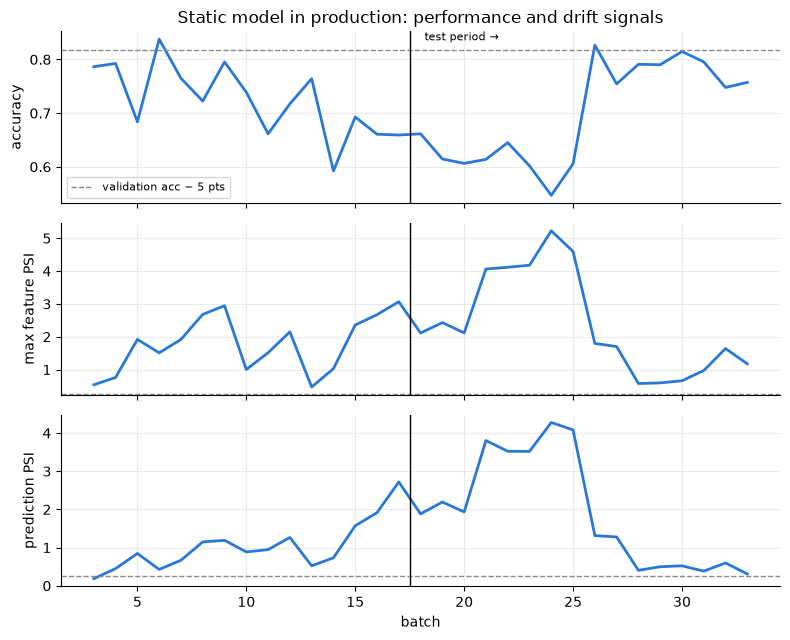

In [44]:
fig, axes = plt.subplots(3, 1, figsize=(8, 6.5), sharex=True)
axes[0].plot(static_log.index, static_log["accuracy"], color=BLUE)
axes[0].axhline(initial["val_acc"] - 0.05, color=GRAY, linestyle="--", linewidth=1, label="validation acc − 5 pts")
axes[0].set(ylabel="accuracy", title="Static model in production: performance and drift signals")
axes[0].legend(loc="lower left", fontsize=8)
axes[1].plot(static_log.index, static_log["max_feature_psi"], color=BLUE)
axes[1].axhline(0.25, color=GRAY, linestyle="--", linewidth=1)
axes[1].set(ylabel="max feature PSI")
axes[2].plot(static_log.index, static_log["prediction_psi"], color=BLUE)
axes[2].axhline(0.25, color=GRAY, linestyle="--", linewidth=1)
axes[2].set(ylabel="prediction PSI", xlabel="batch")
for ax in axes:
    ax.axvline(TEST_PERIOD[0] - 0.5, color="black", linewidth=1)
axes[0].text(TEST_PERIOD[0], axes[0].get_ylim()[1], " test period →", va="top", fontsize=8)
plt.tight_layout()
plt.show()

### Step 3 — Simulate a retraining strategy

In [45]:
def simulate(strategy, acc_tol=0.05, psi_threshold=0.25, every=3, window=3, cooldown=2):
    bundle, rows = fit_with_validation(df[df["batch"] < 3]), []
    for b in STREAM:
        frame = df[df["batch"] == b]
        metrics = monitor(bundle, frame)                       # batch b is served by the current model
        since = b - bundle["trained_through"]                  # end of batch b: its labels arrive → decide for b + 1
        if strategy == "scheduled":
            fire = since >= every
        elif strategy == "label-triggered":
            fire = since >= cooldown and metrics["accuracy"] < bundle["val_acc"] - acc_tol
        elif strategy == "drift-triggered":
            fire = since >= cooldown and metrics["prediction_psi"] > psi_threshold
        else:
            fire = False
        if fire:
            bundle = fit_with_validation(df[(df["batch"] > b - window) & (df["batch"] <= b)])
        rows.append({"batch": b, "accuracy": metrics["accuracy"], "retrained_after": fire})
    return pd.DataFrame(rows).set_index("batch")


def period_summary(log, period):
    part = log.loc[period]
    return {"mean accuracy": part["accuracy"].mean(), "retrains": int(part["retrained_after"].sum())}


start = time.perf_counter()
static_run = simulate("static")
print(f"one simulation takes {time.perf_counter() - start:.1f}s | static on validation period: {period_summary(static_run, VALIDATION_PERIOD)}")

one simulation takes 0.2s | static on validation period: {'mean accuracy': np.float64(0.7246527777777778), 'retrains': 0}


### Step 4 — Tune each strategy on the validation period only

In [46]:
grid = {
    "scheduled": [{"every": e} for e in (2, 3, 6)],
    "label-triggered": [{"acc_tol": t} for t in (0.03, 0.05, 0.08)],
    "drift-triggered": [{"psi_threshold": t} for t in (0.25, 0.5, 1.0)],
}
runs, tuning_rows, chosen = {"static": ({}, static_run)}, [], {"static": {}}
for strategy, options in grid.items():
    for params in options:
        log = simulate(strategy, **params)
        runs[(strategy, tuple(params.items()))] = (params, log)
        tuning_rows.append({"strategy": strategy, "params": params, **period_summary(log, VALIDATION_PERIOD)})
tuning = pd.DataFrame(tuning_rows)
print(tuning.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

for strategy in grid:
    candidates = tuning[tuning["strategy"] == strategy].sort_values(["mean accuracy", "retrains"], ascending=[False, True])
    chosen[strategy] = candidates.iloc[0]["params"]
print("\nchosen on validation:", chosen)

       strategy                  params  mean accuracy  retrains
      scheduled            {'every': 2}          0.756         7
      scheduled            {'every': 3}          0.780         5
      scheduled            {'every': 6}          0.757         2
label-triggered       {'acc_tol': 0.03}          0.787         2
label-triggered       {'acc_tol': 0.05}          0.787         2
label-triggered       {'acc_tol': 0.08}          0.776         2
drift-triggered {'psi_threshold': 0.25}          0.756         7
drift-triggered  {'psi_threshold': 0.5}          0.781         5
drift-triggered  {'psi_threshold': 1.0}          0.763         3

chosen on validation: {'static': {}, 'scheduled': {'every': 3}, 'label-triggered': {'acc_tol': 0.03}, 'drift-triggered': {'psi_threshold': 0.5}}


### Step 5 — Compare strategies on the untouched test period

In [47]:
final_logs = {"static": static_run}
for strategy in grid:
    final_logs[strategy] = runs[(strategy, tuple(chosen[strategy].items()))][1]

results = pd.DataFrame({name: period_summary(log, TEST_PERIOD) for name, log in final_logs.items()}).T
results["accuracy gain vs static (pts)"] = (results["mean accuracy"] - results.loc["static", "mean accuracy"]) * 100
print(results.to_string(float_format=lambda v: f"{v:.3f}"))

best = results["mean accuracy"].idxmax()
print(f"\n🏆 best on the test period: {best} ({results.loc[best, 'mean accuracy']:.1%}, {int(results.loc[best, 'retrains'])} retrains)")
triggered = ["label-triggered", "drift-triggered"]
cheapest_good = results.drop(index="static")
cheapest_good = cheapest_good[cheapest_good["mean accuracy"] >= results["mean accuracy"].max() - 0.01].sort_values("retrains").index[0]
print(f"💰 fewest retrains within 1 point of the best: {cheapest_good} ({int(results.loc[cheapest_good, 'retrains'])} retrains)")
print(f"📉 staying static costs {results.loc[best, 'mean accuracy'] - results.loc['static', 'mean accuracy']:.1%} accuracy on the test period")

                 mean accuracy  retrains  accuracy gain vs static (pts)
static                   0.698     0.000                          0.000
scheduled                0.734     5.000                          3.530
label-triggered          0.721     4.000                          2.305
drift-triggered          0.746     5.000                          4.767

🏆 best on the test period: drift-triggered (74.6%, 5 retrains)
💰 fewest retrains within 1 point of the best: drift-triggered (5 retrains)
📉 staying static costs 4.8% accuracy on the test period


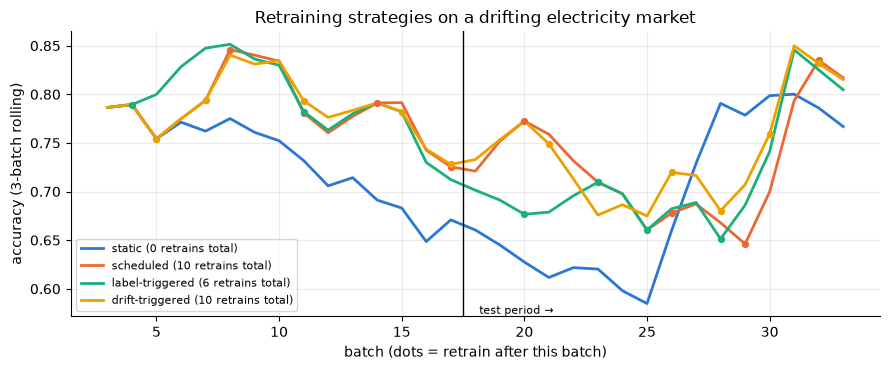

In [48]:
fig, ax = plt.subplots(figsize=(9, 3.8))
for (name, log), color in zip(final_logs.items(), [BLUE, ORANGE, AQUA, YELLOW]):
    rolling = log["accuracy"].rolling(3, min_periods=1).mean()
    ax.plot(log.index, rolling, color=color, label=f"{name} ({int(log['retrained_after'].sum())} retrains total)")
    retrain_batches = log.index[log["retrained_after"]]
    ax.scatter(retrain_batches, rolling.loc[retrain_batches], color=color, s=18, zorder=3)
ax.axvline(TEST_PERIOD[0] - 0.5, color="black", linewidth=1)
ax.text(TEST_PERIOD[0], ax.get_ylim()[0], " test period →", va="bottom", fontsize=8)
ax.set(xlabel="batch (dots = retrain after this batch)", ylabel="accuracy (3-batch rolling)",
       title="Retraining strategies on a drifting electricity market")
ax.legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

### Step 6 — Investigate the worst static batch with Evidently

In [49]:
worst_batch = int(static_log.loc[TEST_PERIOD, "accuracy"].idxmin())
print(f"worst static batch in the test period: {worst_batch} (accuracy {static_log.loc[worst_batch, 'accuracy']:.1%}, "
      f"worst feature by PSI: {static_log.loc[worst_batch, 'worst_feature']})")

if not HAS_EVIDENTLY:
    print("⏭️ Skipped the Evidently report: Evidently is not installed (see ⚙️ Setup).")
else:
    worst_frame = with_predictions(df[df["batch"] == worst_batch], static)
    worst_ds = Dataset.from_pandas(worst_frame, data_definition=definition)
    investigation = Report([DataDriftPreset(columns=FEATURES + ["prob_up"]), ClassificationPreset()]).run(reference_data=ref_ds, current_data=worst_ds)
    report_path = OUTPUT_DIR / f"evidently_investigation_batch{worst_batch}.html"
    investigation.save_html(str(report_path))
    values = investigation.dict()["metrics"]
    drift_summary = next(m["value"] for m in values if m["config"]["type"].endswith("DriftedColumnsCount"))
    accuracy_value = next(m["value"] for m in values if m["config"]["type"].endswith("Accuracy"))
    drift_scores = sorted(((m["config"]["column"], m["value"], m["config"]["method"]) for m in values if m["config"]["type"].endswith("ValueDrift")),
                          key=lambda item: -item[1])
    print(f"Evidently: {drift_summary['count']:.0f} of {len(drift_scores)} columns drifted ({drift_summary['share']:.0%}); accuracy {accuracy_value:.1%}")
    print("largest drift scores:", [(c, round(v, 2), method) for c, v, method in drift_scores[:3]])
    print(f"report saved to {report_path}")

worst static batch in the test period: 24 (accuracy 54.7%, worst feature by PSI: nswprice)


Evidently: 6 of 8 columns drifted (75%); accuracy 54.7%
largest drift scores: [('transfer', np.float64(212.86), 'Wasserstein distance (normed)'), ('vicdemand', np.float64(132.36), 'Wasserstein distance (normed)'), ('vicprice', np.float64(1.59), 'Wasserstein distance (normed)')]
report saved to _outputs/evidently_investigation_batch24.html


**Stretch goals**
1. Add an **expanding-window** variant of the label-triggered strategy and compare it with the 12-week sliding window.
2. Make the label trigger **debounced** (Exercise 5) or require the Wilson interval (section 11) to be below the threshold, and see how the retrain count changes.
3. Simulate a **label delay of 2 batches** (labels for batch *b* only usable after batch *b + 2*) — how much does the label-triggered strategy lose?
4. Add a **champion/challenger guardrail**: promote a retrained model only if it beats the current model on the latest labelled batch.

### 🗣️ How to talk about this in an interview
- "I replayed 2.5 years of the ELEC2 electricity dataset in 4-week batches and showed a static model's accuracy decays by double digits — real concept drift, not a synthetic toy."
- "The monitor logged data-quality problems, per-feature PSI, prediction PSI, predicted-class rate, and delayed-label accuracy per batch; label-free signals correlated with accuracy but also fired on harmless seasonal drift."
- "I compared static, scheduled, label-triggered, and drift-triggered retraining. Thresholds and schedules were tuned only on an early validation period, and the comparison used a later test period."
- "The trade-off is accuracy vs number of retrains: triggers spend compute only when needed, but on volatile data the textbook PSI 0.25 threshold retrained more often and scored lower than a threshold calibrated on the validation period — thresholds must be calibrated, and the ranking of strategies can change between periods."
- "For investigation I generated Evidently drift and classification reports for the worst batch, and verified my own PSI, JS, Wasserstein, and KS implementations reproduce Evidently's numbers exactly."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. What's the difference between data drift, concept drift, and label shift?**

<details><summary>Show answer</summary>

- **30-second answer:** Data drift (covariate shift) is a change in P(X), the inputs; concept drift is a change in P(Y|X), the relationship between inputs and the answer; label (prior) shift is a change in P(Y), how common each outcome is. Only concept drift means the learned mapping itself is wrong.
- **Go deeper:** Data drift may be harmless if the model extrapolates well in the new region (we saw many drifted-but-fine batches); concept drift can hurt with no input drift at all. Label shift can often be corrected by re-weighting or re-calibrating thresholds if P(X|Y) is stable.
- **❌ Common wrong answer:** "Drift means accuracy dropped." Drift describes data; accuracy is the consequence you measure separately.

</details>

**Q2. How can you detect problems when labels are delayed or unavailable?**

<details><summary>Show answer</summary>

- **30-second answer:** Monitor what you do have: data quality, feature drift (weighted by importance), prediction distribution and predicted-class rate, confidence/uncertainty, and business or human-feedback proxies. Validate on history that these signals actually move with performance.
- **Go deeper:** Get a trickle of labels via human review or delayed outcomes; compute performance by cohort as labels mature; use early proxy labels (e.g. first missed payment). For embeddings/text, monitor embedding drift (e.g. a domain classifier or distance between centroid distributions).
- **❌ Common wrong answer:** "Without labels you can't monitor a model."

</details>

**Q3. What PSI thresholds would you use, and what are PSI's weaknesses?**

<details><summary>Show answer</summary>

- **30-second answer:** Conventionally < 0.1 stable, 0.1–0.25 moderate, > 0.25 major — as a starting point. Calibrate with historical windows where the model was fine, per feature.
- **Go deeper:** PSI depends on binning (quantile vs equal-width vs Sturges, number of bins) and on the ε for empty bins; it's biased upward on small samples; it can't see drift from a constant reference column; it ignores *where* in the range the change happened. It's symmetric in form (a symmetrised KL divergence).
- **❌ Common wrong answer:** "0.25 is a statistically derived significance cutoff." It's an industry convention from credit scoring.

</details>

**Q4. Why do p-values from drift tests mislead on large datasets?**

<details><summary>Show answer</summary>

- **30-second answer:** A test asks whether *any* difference exists; with enough rows, even a trivial shift gives p ≈ 0. In our simulation a 0.05σ shift was "significant" from n = 10,000 while PSI stayed below 0.01. So alerts fire constantly and stop meaning anything.
- **Go deeper:** Use effect sizes (PSI, Wasserstein, JS) with calibrated thresholds, or subsample to a fixed n; remember rows are often autocorrelated (not independent), which makes p-values even more over-confident. Across many features, also correct for multiple testing.
- **❌ Common wrong answer:** "Just lower α to 0.001." At a million rows that still flags harmless shifts.

</details>

**Q5. What causes training–serving skew, and how do you prevent it?**

<details><summary>Show answer</summary>

- **30-second answer:** Features computed by different code or data in training vs serving: duplicated logic (Python batch vs Java service), different data sources or freshness (warehouse vs cache), time-travel leakage in training features, unit/normalisation differences, or different handling of missing values. Prevent it with one shared feature definition (feature store or shared library), point-in-time correct training data, and logging serving features to compare with recomputed ones.
- **Go deeper:** Train on **logged serving features** where possible; run a skew check (per-feature distribution comparison between logged and recomputed values) in CI and in production; version feature code with the model.
- **❌ Common wrong answer:** "It's just data drift." Skew exists from day one and is a bug, not a change in the world.

</details>

**Q6. You check 200 features for drift every day. What goes wrong and how do you fix it?**

<details><summary>Show answer</summary>

- **30-second answer:** Multiple testing: at α = 0.05, the chance of at least one false alarm is 1 − 0.95²⁰⁰ ≈ 100%, so you get alerts every day and alert fatigue. Correct with Bonferroni/BH, use effect-size thresholds calibrated on history, require persistence, and prioritise important features and model-level signals.
- **Go deeper:** Group features, alert on a dataset-level drift share, or use a multivariate detector (a domain classifier trained to separate reference vs current). Route low-priority drift to dashboards, not pagers.
- **❌ Common wrong answer:** "More features monitored is always safer."

</details>

### 💻 Coding

**Q7. Implement PSI for a numeric feature.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```python
  def psi(ref, cur, bins=10, eps=1e-4):
      inner = np.unique(np.quantile(ref, np.linspace(0, 1, bins + 1))[1:-1])
      edges = np.concatenate([[-np.inf], inner, [np.inf]])
      r = np.clip(np.histogram(ref, edges)[0] / len(ref), eps, None)
      c = np.clip(np.histogram(cur, edges)[0] / len(cur), eps, None)
      return float(np.sum((c - r) * np.log(c / r)))
  ```
- **Go deeper:** Bin edges come from the **reference** only and are stored with the model so every window uses the same bins; open-ended outer bins catch out-of-range values; `np.unique` handles repeated quantiles in discrete features.
- **❌ Common wrong answer:** Computing bins on the current data (or on each window separately), which makes windows incomparable.

</details>

**Q8. Compute the KS statistic for two samples without scipy. What's the complexity?**

<details><summary>Show answer</summary>

- **30-second answer:** Sort both samples; evaluate both empirical CDFs at every observed value with `np.searchsorted(sorted, grid, side="right") / n`; return the max absolute difference. O((n + m) log(n + m)).
- **Go deeper:** The p-value uses the Kolmogorov distribution with effective size nm/(n+m): p ≈ 2 Σ (−1)^(k−1) e^(−2k²λ²), λ = √(nm/(n+m))·D; scipy uses exact computation for small samples. For streaming data, approximate CDFs with sketches (t-digest, KLL).
- **❌ Common wrong answer:** Comparing CDFs only at the points of one sample, which can miss the maximum gap.

</details>

### 🐛 Debugging Scenarios

**Q9. Accuracy dropped 8 points last month, but none of your feature drift alerts fired. What could be happening?**

<details><summary>Show answer</summary>

- **30-second answer:** Concept drift (same inputs, different correct answers), label shift, a label-pipeline bug (labels joined wrongly or definition changed), drift inside a segment that averages out globally, or interaction effects that per-feature univariate tests can't see.
- **Go deeper:** Slice performance by segment and time; check label quality and the join; compare P(Y|X) on key slices (e.g. calibration curves); try a multivariate drift detector; check whether an upstream change altered a feature's *meaning* without changing its distribution.
- **❌ Common wrong answer:** "No drift means the drop is random noise." Check the interval and the label pipeline first.

</details>

**Q10. Drift alerts fire every week, but model performance is fine. What do you do?**

<details><summary>Show answer</summary>

- **30-second answer:** The alerts aren't actionable: recalibrate thresholds on history (seasonality!), switch from p-values to effect sizes, use a seasonal or sliding reference, weight by feature importance, debounce, and page only on performance or prediction-level signals.
- **Go deeper:** We saw exactly this: about half the batches with major feature PSI kept good accuracy, and in the mini project the textbook PSI-0.25 retraining trigger fired more often, and scored lower, than a threshold calibrated on the validation period. Keep the drift data on dashboards for investigation.
- **❌ Common wrong answer:** "Retrain every time an alert fires."

</details>

**Q11. After a deployment, the model's predicted-positive rate jumps from 3% to 20% overnight. How do you debug it?**

<details><summary>Show answer</summary>

- **30-second answer:** Suspect the pipeline before the world: check data-quality validators (nulls, defaults, units, schema), compare logged serving features with training features for skew, confirm the right model version and preprocessing artifact were deployed, and look at which features shifted most. Roll back if impact is high.
- **Go deeper:** A sudden step change at a deploy time points to code/config; a gradual change points to the world. Keep per-version prediction logs so you can diff old vs new model on the same requests (shadow mode would have caught it before release).
- **❌ Common wrong answer:** "Customer behaviour changed; retrain on the new data." Retraining on buggy features bakes the bug in.

</details>

### 🏗️ Design

**Q12. How do you choose a retraining cadence?**

<details><summary>Show answer</summary>

- **30-second answer:** Replay history: train at several points, measure how fast performance decays, and weigh the cost of stale predictions against retraining and deployment cost/risk. Start with a schedule shorter than the decay time, add performance/drift triggers with guardrails (minimum labels, cooldown, champion/challenger validation), and revisit periodically.
- **Go deeper:** Label delay sets a floor on how fast triggers can react. Decide the training window too (sliding vs expanding — on ELEC2 the recent window won). Automate the pipeline so retraining is cheap and safe before optimising the cadence.
- **❌ Common wrong answer:** "Retrain daily to be safe" or "retrain when someone notices."

</details>

**Q13. Design monitoring for a real-time model serving 5,000 requests per second.**

<details><summary>Show answer</summary>

- **30-second answer:** Log request id, model version, features, prediction, and latency asynchronously to a stream (sampling if needed); real-time metrics for latency, errors, and prediction rate in Prometheus/Grafana; windowed batch jobs (hourly/daily) for data quality, drift, and prediction drift written as JSON metrics; join delayed labels by request id for performance by cohort; alerts routed by severity; retraining and shadow/canary rollout wired to the registry.
- **Go deeper:** Never block the request path on monitoring; use approximate sketches for streaming distributions; keep reference statistics (bin edges, quantiles) versioned with the model; monitor per important segment; set SLOs and runbooks for each alert.
- **❌ Common wrong answer:** "Run an Evidently report on every request."

</details>

**Q14. What is a feedback loop in production ML, and how do you guard against it?**

<details><summary>Show answer</summary>

- **30-second answer:** The model's decisions shape the data it's retrained on — a recommender only sees clicks on items it showed, a credit model only sees repayment for approved applicants, a fraud model only gets labels for flagged transactions — so errors and biases reinforce themselves and monitoring looks rosier than reality.
- **Go deeper:** Keep a small randomised exploration/holdout slice, log propensities for off-policy evaluation, evaluate on unbiased samples, use reject inference carefully in credit, and watch diversity/coverage metrics over time.
- **❌ Common wrong answer:** "More data from production always makes the model better."

</details>

## 🧪 Quick Quiz

**1.** What is the PSI of a sample compared with itself?
<details><summary>Answer</summary>

`0.0` — every bin share matches, so every term is 0 (we printed this sanity check in section 3).
</details>

**2.** Evidently's `DataDriftPreset` gets a numerical column with 4,032 reference rows and hundreds of unique values. Which method does it use by default, and what's the threshold?
<details><summary>Answer</summary>

Normalised Wasserstein distance (distance ÷ reference std) with threshold 0.1 — the reference has more than 1,000 rows (section 13's table shows exactly this).
</details>

**3.** Two samples of 1,000,000 rows differ by 0.05 standard deviations. Roughly what does the KS test p-value look like, and does it mean the model is in trouble?
<details><summary>Answer</summary>

Essentially 0 ("highly significant"), yet the effect is tiny (PSI well below 0.01 in section 7). Significance ≠ importance.
</details>

**4.** For `a = [1, 2, 3, 4]` and `b = [3, 4, 5, 6]`, what are the KS statistic and the Wasserstein-1 distance?
<details><summary>Answer</summary>

KS D = 0.5 (section 4's Your Turn). Wasserstein-1 = 2.0: both have 4 points and `sort(b) − sort(a)` is 2 everywhere, so all mass moves 2 units.
</details>

**5.** You test 6 independent features at α = 0.05 each. What's the chance of at least one false alarm when nothing drifted?
<details><summary>Answer</summary>

1 − 0.95⁶ ≈ 26.5% (Exercise 3). With Bonferroni (α = 0.05/6 ≈ 0.0083 per test) it drops back to about 5%.
</details>

## 📚 Resources

### 📖 Official Docs
- [What is Evidently? — Documentation](https://docs.evidentlyai.com/) — Reports, presets, metrics, and the 0.7 API
- [Customize Data Drift — Evidently Documentation](https://docs.evidentlyai.com/metrics/customize_data_drift) — every drift method, threshold, and per-column option
- [scipy.stats.ks_2samp](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ks_2samp.html) — exact vs asymptotic p-values
- [Rules of Machine Learning (Google)](https://developers.google.com/machine-learning/guides/rules-of-ml) — practical rules on training–serving skew and monitoring

### 🎥 Videos
- [PyData — Emeli Dral: Detecting drift](https://www.youtube.com/watch?v=0wdCMvU1vCQ) (~30 min) — Evidently's co-founder on choosing drift methods and reading results; complements sections 3–8
- [Evidently AI — Data and prediction drift in ML (code practice)](https://www.youtube.com/watch?v=oO1K4CaWxt0) (~21 min) — hands-on drift detection in Python from the free ML observability course
- [ODS AI — Emeli Dral: The day after deployment](https://www.youtube.com/watch?v=_xjtxnFJakY) (~45 min) — how to set up monitoring layers and what to alert on; good for design-round answers

### 📄 Papers
- [Rabanser, Günnemann & Lipton (2019) — Failing Loudly: An Empirical Study of Methods for Detecting Dataset Shift](https://arxiv.org/abs/1810.11953) — compares univariate tests, multiple testing corrections, and multivariate detectors
- [Lu et al. (2018) — Learning under Concept Drift: A Review](https://arxiv.org/abs/2004.05785) — taxonomy of drift types, detection, and adaptation strategies
- [Breck et al. (2017) — The ML Test Score: A Rubric for ML Production Readiness](https://research.google/pubs/the-ml-test-score-a-rubric-for-ml-production-readiness-and-technical-debt-reduction/) — Google's checklist, including monitoring tests

### 📘 Books & Courses
- [Chip Huyen — Data Distribution Shifts and Monitoring](https://huyenchip.com/2022/02/07/data-distribution-shifts-and-monitoring.html) — a long free chapter-style post from *Designing Machine Learning Systems*
- [Evidently — Open-source ML observability course](https://www.evidentlyai.com/ml-observability-course) — free course with videos and code
- [MLOps Zoomcamp — Monitoring module](https://github.com/DataTalksClub/mlops-zoomcamp/tree/main/05-monitoring) — free DataTalksClub module building a monitoring service with Evidently, Grafana, and a database

### 🏋️ Practice
- [OpenML — electricity (data id 151)](https://www.openml.org/search?type=data&id=151) — the dataset used here; try other drift datasets from the same site and replay them with this notebook's monitor

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / formula |
|---|---|---|
| Data drift | P(X) changes | compare feature distributions: PSI, KS, Wasserstein, JS |
| Concept drift | P(Y\|X) changes | needs labels / proxies: performance by window |
| Label shift | P(Y) changes | class-rate monitoring, re-calibration |
| Training–serving skew | features differ between training and serving | shared feature code, log serving features, skew check |
| PSI | binned distribution shift | Σ (c − r)·ln(c/r); ~0.1 / 0.25 bands; bins from reference |
| KS | max CDF gap (+ p-value) | `stats.ks_2samp`; p-values collapse at large n |
| Wasserstein | area between CDFs (units) | `stats.wasserstein_distance` ÷ ref std |
| Chi-square / JS | categorical drift | `stats.chisquare(obs, f_exp)` · `jensenshannon(p, q, base=2)` |
| Multiple testing | false alarms across features | FWER = 1 − (1−α)^k · Bonferroni α/k · `false_discovery_control` |
| Data quality | schema, nulls, ranges, constants | validators at ingestion, training, serving |
| No labels | early warning | prediction PSI, predicted-class rate, confidence, proxies |
| Delayed labels | performance with uncertainty | per-window accuracy + Wilson interval, cohorts |
| Retraining | keep the model fresh | static · scheduled · triggered (+ cooldown, validation) · sliding vs expanding window |
| Evidently | reports + JSON metrics | `Report([DataDriftPreset(), ClassificationPreset()]).run(reference_data=, current_data=)` |
| Safe rollout | monitor before full traffic | shadow → canary → A/B; watch feedback loops |

## ➡️ What's Next

**[06 · Kubeflow Pipelines](06_Kubeflow_Pipelines.ipynb)** (optional) — run monitoring and retraining as containerised, reproducible pipeline steps on Kubernetes. Or go straight to **[FastAPI](../10_Model_Serving/01_FastAPI.ipynb)** to build the model API whose requests and predictions you now know how to log and monitor.